# Counterfactual Explanation in Allegro Pay

**Warsaw University of Technology — Final Project**

---

This notebook provides boilerplate code to help you get started. It covers:

1. Environment verification & imports
2. Data loading & initial EDA
3. Feature engineering (skeleton)
4. Feature selection (Boruta)
5. Model training (LightGBM)
6. Model serialization
7. Counterfactual generation (DiCE & Alibi)
8. Evaluation & Benchmarking (DALEX)

> **Instructions:** Fork this repo, fill in the `TODO` sections, and extend the analysis.
> Delete or modify this boilerplate as your project evolves.

In [ ]:
#to dump w buszu
#pip freeze > requirements.txt

#to install dependencies 
pip install -r requirements.txt

## 1. Imports & Configuration

In [1]:
# Standard library
import pickle
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
#import optbinning
#from optbinning import BinningProcess
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
#import optuna
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    brier_score_loss,
    f1_score,
    ConfusionMatrixDisplay
)

from sklearn.calibration import calibration_curve

import xgboost as xgb    # Uncomment if using XGBoost
#from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
#import shap
# Counterfactual Explanation packages
import dice_ml
import alibi               # Uncomment when implementing Alibi
from dice_ml import Dice
from alibi.explainers import ALE, plot_ale
from alibi.explainers import AnchorTabular
import dalex as dx
# Project config
import sys
sys.path.insert(0, str(Path.cwd().parent))  # Allow imports from src/
from src.config import (
    RANDOM_SEED,
    DATA_DIR,
    MODELS_DIR,
    TARGET_COLUMN,
    TEST_SIZE,
    N_FEATURES_TO_SELECT,
    N_COUNTERFACTUAL_EXAMPLES,
)

import subprocess
import zipfile

# Reproducibility
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Random seed: {RANDOM_SEED}")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")

c:\Users\stani\miniconda3\envs\explain\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Random seed: 42
Data directory: C:\Users\stani\wut-counterfactual-explanations\data
Models directory: C:\Users\stani\wut-counterfactual-explanations\models


In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


## 2. Data Loading & Feature engineering 

In [2]:
# Load the main application training data
app_train = pd.read_csv(DATA_DIR / "application_train.csv")
pd.set_option('display.max_columns', 500)
print(f"Shape: {app_train.shape}")
print(f"\nTarget distribution:\n{app_train[TARGET_COLUMN].value_counts(normalize=True)}")

Shape: (307511, 122)

Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [3]:
col_to_delete_picked_by_hand = [
    "NAME_TYPE_SUITE",
    "REGION_POPULATION_RELATIVE",
    "DAYS_ID_PUBLISH",
    "FLAG_MOBIL",
    "FLAG_EMP_PHONE",
    "FLAG_WORK_PHONE",
    "FLAG_CONT_MOBILE",
    "FLAG_PHONE",
    "FLAG_EMAIL",
    "WEEKDAY_APPR_PROCESS_START",
    "HOUR_APPR_PROCESS_START",
    "REG_REGION_NOT_LIVE_REGION",
    "REG_REGION_NOT_WORK_REGION",
    "LIVE_REGION_NOT_WORK_REGION",
    "REG_CITY_NOT_LIVE_CITY",
    "REG_CITY_NOT_WORK_CITY",
    "LIVE_CITY_NOT_WORK_CITY",
    "APARTMENTS_AVG",
    "BASEMENTAREA_AVG",
    "YEARS_BEGINEXPLUATATION_AVG",
    "YEARS_BUILD_AVG",
    "COMMONAREA_AVG",
    "ELEVATORS_AVG",
    "ENTRANCES_AVG",
    "FLOORSMAX_AVG",
    "FLOORSMIN_AVG",
    "LANDAREA_AVG",
    "LIVINGAPARTMENTS_AVG",
    "LIVINGAREA_AVG",
    "NONLIVINGAPARTMENTS_AVG",
    "NONLIVINGAREA_AVG",
    "APARTMENTS_MODE",
    "BASEMENTAREA_MODE",
    "YEARS_BEGINEXPLUATATION_MODE",
    "YEARS_BUILD_MODE",
    "COMMONAREA_MODE",
    "ELEVATORS_MODE",
    "ENTRANCES_MODE",
    "FLOORSMAX_MODE",
    "FLOORSMIN_MODE",
    "LANDAREA_MODE",
    "LIVINGAPARTMENTS_MODE",
    "LIVINGAREA_MODE",
    "NONLIVINGAPARTMENTS_MODE",
    "NONLIVINGAREA_MODE",
    "APARTMENTS_MEDI",
    "BASEMENTAREA_MEDI",
    "YEARS_BEGINEXPLUATATION_MEDI",
    "YEARS_BUILD_MEDI",
    "COMMONAREA_MEDI",
    "ELEVATORS_MEDI",
    "ENTRANCES_MEDI",
    "FLOORSMAX_MEDI",
    "FLOORSMIN_MEDI",
    "LANDAREA_MEDI",
    "LIVINGAPARTMENTS_MEDI",
    "LIVINGAREA_MEDI",
    "NONLIVINGAPARTMENTS_MEDI",
    "NONLIVINGAREA_MEDI",
    "FONDKAPREMONT_MODE",
    "HOUSETYPE_MODE",
    "TOTALAREA_MODE",
    "FLAG_DOCUMENT_2",
    "FLAG_DOCUMENT_3",
    "FLAG_DOCUMENT_4",
    "FLAG_DOCUMENT_5",
    "FLAG_DOCUMENT_6",
    "FLAG_DOCUMENT_7",
    "FLAG_DOCUMENT_8",
    "FLAG_DOCUMENT_9",
    "FLAG_DOCUMENT_10",
    "FLAG_DOCUMENT_11",
    "FLAG_DOCUMENT_12",
    "FLAG_DOCUMENT_13",
    "FLAG_DOCUMENT_14",
    "FLAG_DOCUMENT_15",
    "FLAG_DOCUMENT_16",
    "FLAG_DOCUMENT_17",
    "FLAG_DOCUMENT_18",
    "FLAG_DOCUMENT_19",
    "FLAG_DOCUMENT_20",
    "FLAG_DOCUMENT_21",
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]

In [4]:
app_train = app_train.drop(columns=col_to_delete_picked_by_hand)

In [5]:
def time_bucket(x):
    if x >= -6:
        return 'last_6m'
    elif x >= -24 and x < -6:
        return '24_6m'
    else:
        return 'older'

In [6]:
# load bureau data, filter by currency, drop unnecessary columns and aggregate numerical and categorical features 
bureau = pd.read_csv(DATA_DIR / "bureau.csv")
bureau = bureau[bureau['CREDIT_CURRENCY'] == 'currency 1']
bureau = bureau.drop(columns=['CREDIT_CURRENCY', 'SK_ID_BUREAU'])
num_cols_bureau = bureau.select_dtypes(include='number').columns.drop(['SK_ID_CURR'], errors='ignore').tolist()
cat_cols_bureau = ['CREDIT_ACTIVE', 'CREDIT_TYPE']
num_agg_bureau = bureau.groupby('SK_ID_CURR')[num_cols_bureau].agg(['mean','max', 'std', 'count'])
num_agg_bureau.columns = ['_'.join(col) for col in num_agg_bureau.columns]
cat_agg_bureau = pd.DataFrame(index=bureau['SK_ID_CURR'].unique())
for col in cat_cols_bureau:
    dummies = pd.get_dummies(bureau[['SK_ID_CURR', col]], columns=[col], dummy_na=True)
    cat_agg_bureau = cat_agg_bureau.join(dummies.groupby('SK_ID_CURR').sum())
bureau_agg = num_agg_bureau.join(cat_agg_bureau)
bureau_agg = bureau_agg.reset_index()
bureau_agg = bureau_agg.rename(columns={col: f"BR_{col}" for col in bureau_agg.columns if col != 'SK_ID_CURR'})
temp = bureau_agg.columns
for col in temp:
    if 'mean' in col:
        parts = col.split('_mean')
        feature = parts[0]
        #feature_data = parts[1]
        max_col = f"{feature}_max"
        std_col = f"{feature}_std"
        if max_col in bureau_agg.columns:
            bureau_agg[f"{feature}_max_to_mean"] = (
                bureau_agg[max_col] / (bureau_agg[col] + 1e-6)
            )
        if std_col in bureau_agg.columns:
            bureau_agg[f"{feature}_std_to_mean"] = (
                bureau_agg[std_col] / (bureau_agg[col] + 1e-6)
            )
        bureau_agg = bureau_agg.drop(columns = std_col)

In [7]:
# load credit card balance data, drop unnecessary columns, create time buckets and aggregate numerical features
credit_card_balance = pd.read_csv(DATA_DIR / "credit_card_balance.csv")
credit_card_balance = credit_card_balance.drop(columns=['NAME_CONTRACT_STATUS'])
credit_card_balance['time_bucket'] = credit_card_balance['MONTHS_BALANCE'].apply(time_bucket)
credit_card_balance = credit_card_balance.drop(columns=['SK_ID_PREV'])
num_cols_credit = credit_card_balance.select_dtypes(include='number').columns.drop(['SK_ID_CURR'], errors='ignore').tolist()
num_agg_credit = credit_card_balance.groupby(['SK_ID_CURR', 'time_bucket'])[num_cols_credit].agg(['mean', 'max', 'std', 'count'])
num_agg_credit.columns = [
    f"{col}_{agg}_{bucket}"
    for col, agg in num_agg_credit.columns
    for bucket in ['']  
]
num_agg_credit = num_agg_credit.unstack('time_bucket')
num_agg_credit.columns = [
    f"{col}{bucket}"
    for col, bucket in num_agg_credit.columns
]
credit_agg = num_agg_credit.reset_index()
credit_agg = credit_agg.rename(columns={col: f"CR_{col}" for col in credit_agg.columns if col != 'SK_ID_CURR'})
for col in credit_agg.columns:
    if 'mean' in col:
        parts = col.split('_mean_')
        feature = parts[0]
        bucket = parts[1]
        max_col = f"{feature}_max_{bucket}"
        std_col = f"{feature}_std_{bucket}"
        if max_col in credit_agg.columns:
            credit_agg[f"{feature}_max_to_mean_{bucket}"] = (
                credit_agg[max_col] / (credit_agg[col] + 1e-6)
            )
        if std_col in credit_agg.columns:
            credit_agg[f"{feature}_std_to_mean_{bucket}"] = (
                credit_agg[std_col] / (credit_agg[col] + 1e-6)
            )
        credit_agg = credit_agg.drop(columns = std_col)

In [8]:
# load POS_CASH balance data, drop unnecessary columns, create time buckets and aggregate numerical features
pos_cash_balance = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
pos_cash_balance = pos_cash_balance.drop(columns=['NAME_CONTRACT_STATUS'])
pos_cash_balance['time_bucket'] = pos_cash_balance['MONTHS_BALANCE'].apply(time_bucket)
pos_cash_balance = pos_cash_balance.drop(columns=['SK_ID_PREV'])
num_cols_pos = pos_cash_balance.select_dtypes(include='number').columns.drop(['SK_ID_CURR'], errors='ignore').tolist()
num_agg_pos = pos_cash_balance.groupby(['SK_ID_CURR', 'time_bucket'])[num_cols_pos].agg(['mean', 'max', 'std', 'count'])
num_agg_pos.columns = [
    f"{col}_{agg}_{bucket}"
    for col, agg in num_agg_pos.columns
    for bucket in [''] 
]
num_agg_pos = num_agg_pos.unstack('time_bucket')
num_agg_pos.columns = [
    f"{col}{bucket}"
    for col, bucket in num_agg_pos.columns
]
pos_agg = num_agg_pos.reset_index()
pos_agg = pos_agg.rename(columns={col: f"PC_{col}" for col in pos_agg.columns if col != 'SK_ID_CURR'})
for col in pos_agg.columns:
    if '_mean_' in col:
        parts = col.split('_mean_')
        feature = parts[0]
        bucket = parts[1]
        max_col = f"{feature}_max_{bucket}"
        std_col = f"{feature}_std_{bucket}"
        if max_col in pos_agg.columns:
            pos_agg[f"{feature}_max_to_mean_{bucket}"] = (
                pos_agg[max_col] / (pos_agg[col] + 1e-6)
            )
        if std_col in pos_agg.columns:
            pos_agg[f"{feature}_std_to_mean_{bucket}"] = (
                pos_agg[std_col] / (pos_agg[col] + 1e-6)
            )
        pos_agg = pos_agg.drop(columns = std_col)

In [9]:
# load previous application data, drop unnecessary columns, and aggregate features
previous_application = pd.read_csv(DATA_DIR / "previous_application.csv")
previous_application = previous_application.drop(columns=['SK_ID_PREV'])
num_cols_previous = previous_application.select_dtypes(include='number').columns.drop('SK_ID_CURR', errors='ignore').tolist()
cat_cols_previous = previous_application.select_dtypes(include='object').columns.drop('SK_ID_CURR', errors='ignore').tolist()
num_agg_previous = previous_application.groupby('SK_ID_CURR')[num_cols_previous].agg(['mean', 'max', 'std', 'count'])
num_agg_previous.columns = ['_'.join(col) for col in num_agg_previous.columns]
cat_agg_previous = pd.DataFrame(index=previous_application['SK_ID_CURR'].unique())
for col in cat_cols_previous:
    dummies = pd.get_dummies(previous_application[['SK_ID_CURR', col]], columns=[col], dummy_na=True)
    cat_agg_previous = cat_agg_previous.join(dummies.groupby('SK_ID_CURR').sum())
previous_agg = num_agg_previous.join(cat_agg_previous)
previous_agg = previous_agg.reset_index()
previous_agg = previous_agg.rename(columns={col: f"PR_{col}" for col in previous_agg.columns if col != 'SK_ID_CURR'})
for col in previous_agg.columns:
    if 'mean' in col:
        parts = col.split('_mean')
        feature = parts[0]
        max_col = f"{feature}_max"
        std_col = f"{feature}_std"
        if max_col in previous_agg.columns:
            previous_agg[f"{feature}_max_to_mean"] = (
                previous_agg[max_col] / (previous_agg[col] + 1e-6)
            )
        if std_col in previous_agg.columns:
            previous_agg[f"{feature}_std_to_mean"] = (
                previous_agg[std_col] / (previous_agg[col] + 1e-6)
            )
        previous_agg = previous_agg.drop(columns = std_col)

In [ ]:
# for now we skip bureau_balance and instalments_payments TODO

In [10]:
final_df = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')\
                    .merge(credit_agg, on='SK_ID_CURR', how='left') \
                    .merge(pos_agg, on='SK_ID_CURR', how='left') \
                    .merge(previous_agg, on='SK_ID_CURR', how='left')

In [11]:
final_df.to_csv(DATA_DIR / "FINAL_FINAL_phone_buckets_6_24.csv", index=False)

## Feature selection 

few schemes to consider 

In [2]:
final_df = pd.read_csv(DATA_DIR / "FINAL_FINAL_phone_buckets_6_24.csv")
final_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PR_DAYS_FIRST_DUE_max_to_mean,PR_DAYS_FIRST_DUE_std_to_mean,PR_DAYS_LAST_DUE_1ST_VERSION_max_to_mean,PR_DAYS_LAST_DUE_1ST_VERSION_std_to_mean,PR_DAYS_LAST_DUE_max_to_mean,PR_DAYS_LAST_DUE_std_to_mean,PR_DAYS_TERMINATION_max_to_mean,PR_DAYS_TERMINATION_std_to_mean,PR_NFLAG_INSURED_ON_APPROVAL_max_to_mean,PR_NFLAG_INSURED_ON_APPROVAL_std_to_mean
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,0.000000,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.561862,-0.704547,0.384335,-0.851281,0.508378,-0.762159,0.503183,-0.769761,1.499998,0.866024
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,0.000000,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,4.010728,2.007153,3.988066,1.992056,2.001578,1.156523,2.001532,1.156469,0.000000,0.000000
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.272324,-0.615404,-0.413282,-1.114222,5.063241,2.271439,5.062708,2.271140,1.666664,0.912869


In [3]:
# classic woe + IV feature selection as the first step 
X = final_df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = final_df['TARGET']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
categorical_vars = [col for col in final_df.columns if final_df[col].dtype == 'object'] 
variable_names = X_train.columns.tolist()
custom_params = {
    "gamma": 0.1,               
    "outlier_detector": "zscore" 
}
binning_fit_params = {col: custom_params for col in variable_names}
binning_process = BinningProcess(
    variable_names=variable_names,
    categorical_variables=categorical_vars,
    binning_fit_params=binning_fit_params, 
    max_n_bins=8,          
    min_bin_size=0.05,  
    selection_criteria={"iv": {"min": 0.005}})
binning_process.fit(X_train, y_train) # important to fit only on train set to avoid data leakage
#X_train_woe = binning_process.transform(X_train)
#X_test_woe = binning_process.transform(X_test)

,variable_names,"['NAME_CONTRACT_TYPE', 'CODE_GENDER', ...]"
,max_n_prebins,20
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,8
,min_bin_size,0.05
,max_bin_size,None
,max_pvalue,None
,max_pvalue_policy,'consecutive'
,selection_criteria,{'iv': {'min': 0.005}}
,fixed_variables,None


In [4]:
summary = binning_process.summary()
top_15_summary = summary.sort_values("iv", ascending=False).head(15)
print("--- Final Model: Top 15 Features ---")
print(top_15_summary[['name', 'iv']].reset_index(drop=True))

--- Final Model: Top 15 Features ---
                                  name        iv
0                         EXT_SOURCE_3  0.334562
1                         EXT_SOURCE_2  0.314303
2                         EXT_SOURCE_1  0.147214
3                  BR_DAYS_CREDIT_mean  0.116101
4           BR_DAYS_CREDIT_UPDATE_mean  0.089684
5                           DAYS_BIRTH   0.08679
6                   BR_DAYS_CREDIT_max  0.084253
7                      AMT_GOODS_PRICE   0.08149
8                      OCCUPATION_TYPE  0.078339
9   BR_DAYS_CREDIT_ENDDATE_max_to_mean  0.070054
10                   ORGANIZATION_TYPE  0.069985
11  BR_AMT_CREDIT_SUM_DEBT_std_to_mean  0.069914
12  BR_DAYS_CREDIT_ENDDATE_std_to_mean  0.069814
13           BR_DAYS_ENDDATE_FACT_mean  0.069781
14         BR_DAYS_CREDIT_ENDDATE_mean  0.063807


In [5]:
# usually we would drop features with IV < 0.02, there is an argument to be made to drop features with IV < 0.03
# to be considered later TODO
low_iv = summary[summary['iv'] < 0.02]['name'].tolist()
final_df_without_low_iv = final_df.drop(columns=low_iv)

In [6]:
final_df_without_low_iv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 86 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   SK_ID_CURR                                        307511 non-null  int64  
 1   TARGET                                            307511 non-null  int64  
 2   AMT_CREDIT                                        307511 non-null  float64
 3   AMT_GOODS_PRICE                                   307233 non-null  float64
 4   NAME_INCOME_TYPE                                  307511 non-null  object 
 5   DAYS_BIRTH                                        307511 non-null  int64  
 6   DAYS_EMPLOYED                                     307511 non-null  int64  
 7   DAYS_REGISTRATION                                 307511 non-null  float64
 8   OWN_CAR_AGE                                       104582 non-null  float64
 9   OCCU

In [7]:
# classic correlation analysis to identify highly correlated pairs of features, the one with the lower IV in each pair will be removed
corr = final_df_without_low_iv.drop(columns = [TARGET_COLUMN, "SK_ID_CURR"]).select_dtypes(include='number').corr()
pairs = corr.stack()
pairs = pairs[pairs.index.get_level_values(0) != pairs.index.get_level_values(1)]  # drop diagonal
pairs = pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)]   # drop duplicates
high_corr = pairs[pairs.abs() > 0.8].sort_values(ascending=False)
to_drop = set()
for var1, var2 in high_corr[high_corr.abs() > 0.8].index:
    if var1 in to_drop or var2 in to_drop:
        continue
    # get IV for both
    iv1 = summary.loc[summary['name'] == var1, 'iv'].values[0]
    iv2 = summary.loc[summary['name'] == var2, 'iv'].values[0]
    # drop the weaker one
    if iv1 >= iv2:
        to_drop.add(var2)
    else:
        to_drop.add(var1)
print(f"Dropping {len(to_drop)} variables: {to_drop}")
final = final_df_without_low_iv.drop(columns=to_drop)

Dropping 28 variables: {'CR_CNT_DRAWINGS_OTHER_CURRENT_count_24_6m', 'CR_AMT_PAYMENT_CURRENT_count_24_6m', 'BR_DAYS_CREDIT_ENDDATE_std_to_mean', 'CR_CNT_DRAWINGS_ATM_CURRENT_count_last_6m', 'CR_CNT_INSTALMENT_MATURE_CUM_max_last_6m', 'PC_SK_DPD_max_to_mean_older', 'PC_SK_DPD_DEF_std_to_mean_older', 'PR_DAYS_TERMINATION_std_to_mean', 'CR_AMT_DRAWINGS_POS_CURRENT_count_last_6m', 'PC_SK_DPD_DEF_max_to_mean_older', 'CR_AMT_DRAWINGS_OTHER_CURRENT_count_last_6m', 'PC_MONTHS_BALANCE_std_to_mean_older', 'AMT_CREDIT', 'CR_CNT_DRAWINGS_OTHER_CURRENT_count_last_6m', 'PC_SK_DPD_mean_older', 'CR_CNT_DRAWINGS_POS_CURRENT_count_24_6m', 'CR_AMT_PAYMENT_CURRENT_count_last_6m', 'PR_DAYS_LAST_DUE_max_to_mean', 'CR_AMT_DRAWINGS_OTHER_CURRENT_count_24_6m', 'BR_AMT_CREDIT_SUM_DEBT_max_to_mean', 'CR_CNT_DRAWINGS_ATM_CURRENT_count_24_6m', 'CR_CNT_DRAWINGS_POS_CURRENT_count_last_6m', 'BR_DAYS_ENDDATE_FACT_count', 'PR_DAYS_LAST_DUE_1ST_VERSION_std_to_mean', 'CR_AMT_PAYMENT_CURRENT_mean_last_6m', 'PC_CNT_INSTALM

In [8]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 58 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   SK_ID_CURR                                        307511 non-null  int64  
 1   TARGET                                            307511 non-null  int64  
 2   AMT_GOODS_PRICE                                   307233 non-null  float64
 3   NAME_INCOME_TYPE                                  307511 non-null  object 
 4   DAYS_BIRTH                                        307511 non-null  int64  
 5   DAYS_EMPLOYED                                     307511 non-null  int64  
 6   DAYS_REGISTRATION                                 307511 non-null  float64
 7   OWN_CAR_AGE                                       104582 non-null  float64
 8   OCCUPATION_TYPE                                   211120 non-null  object 
 9   ORGA

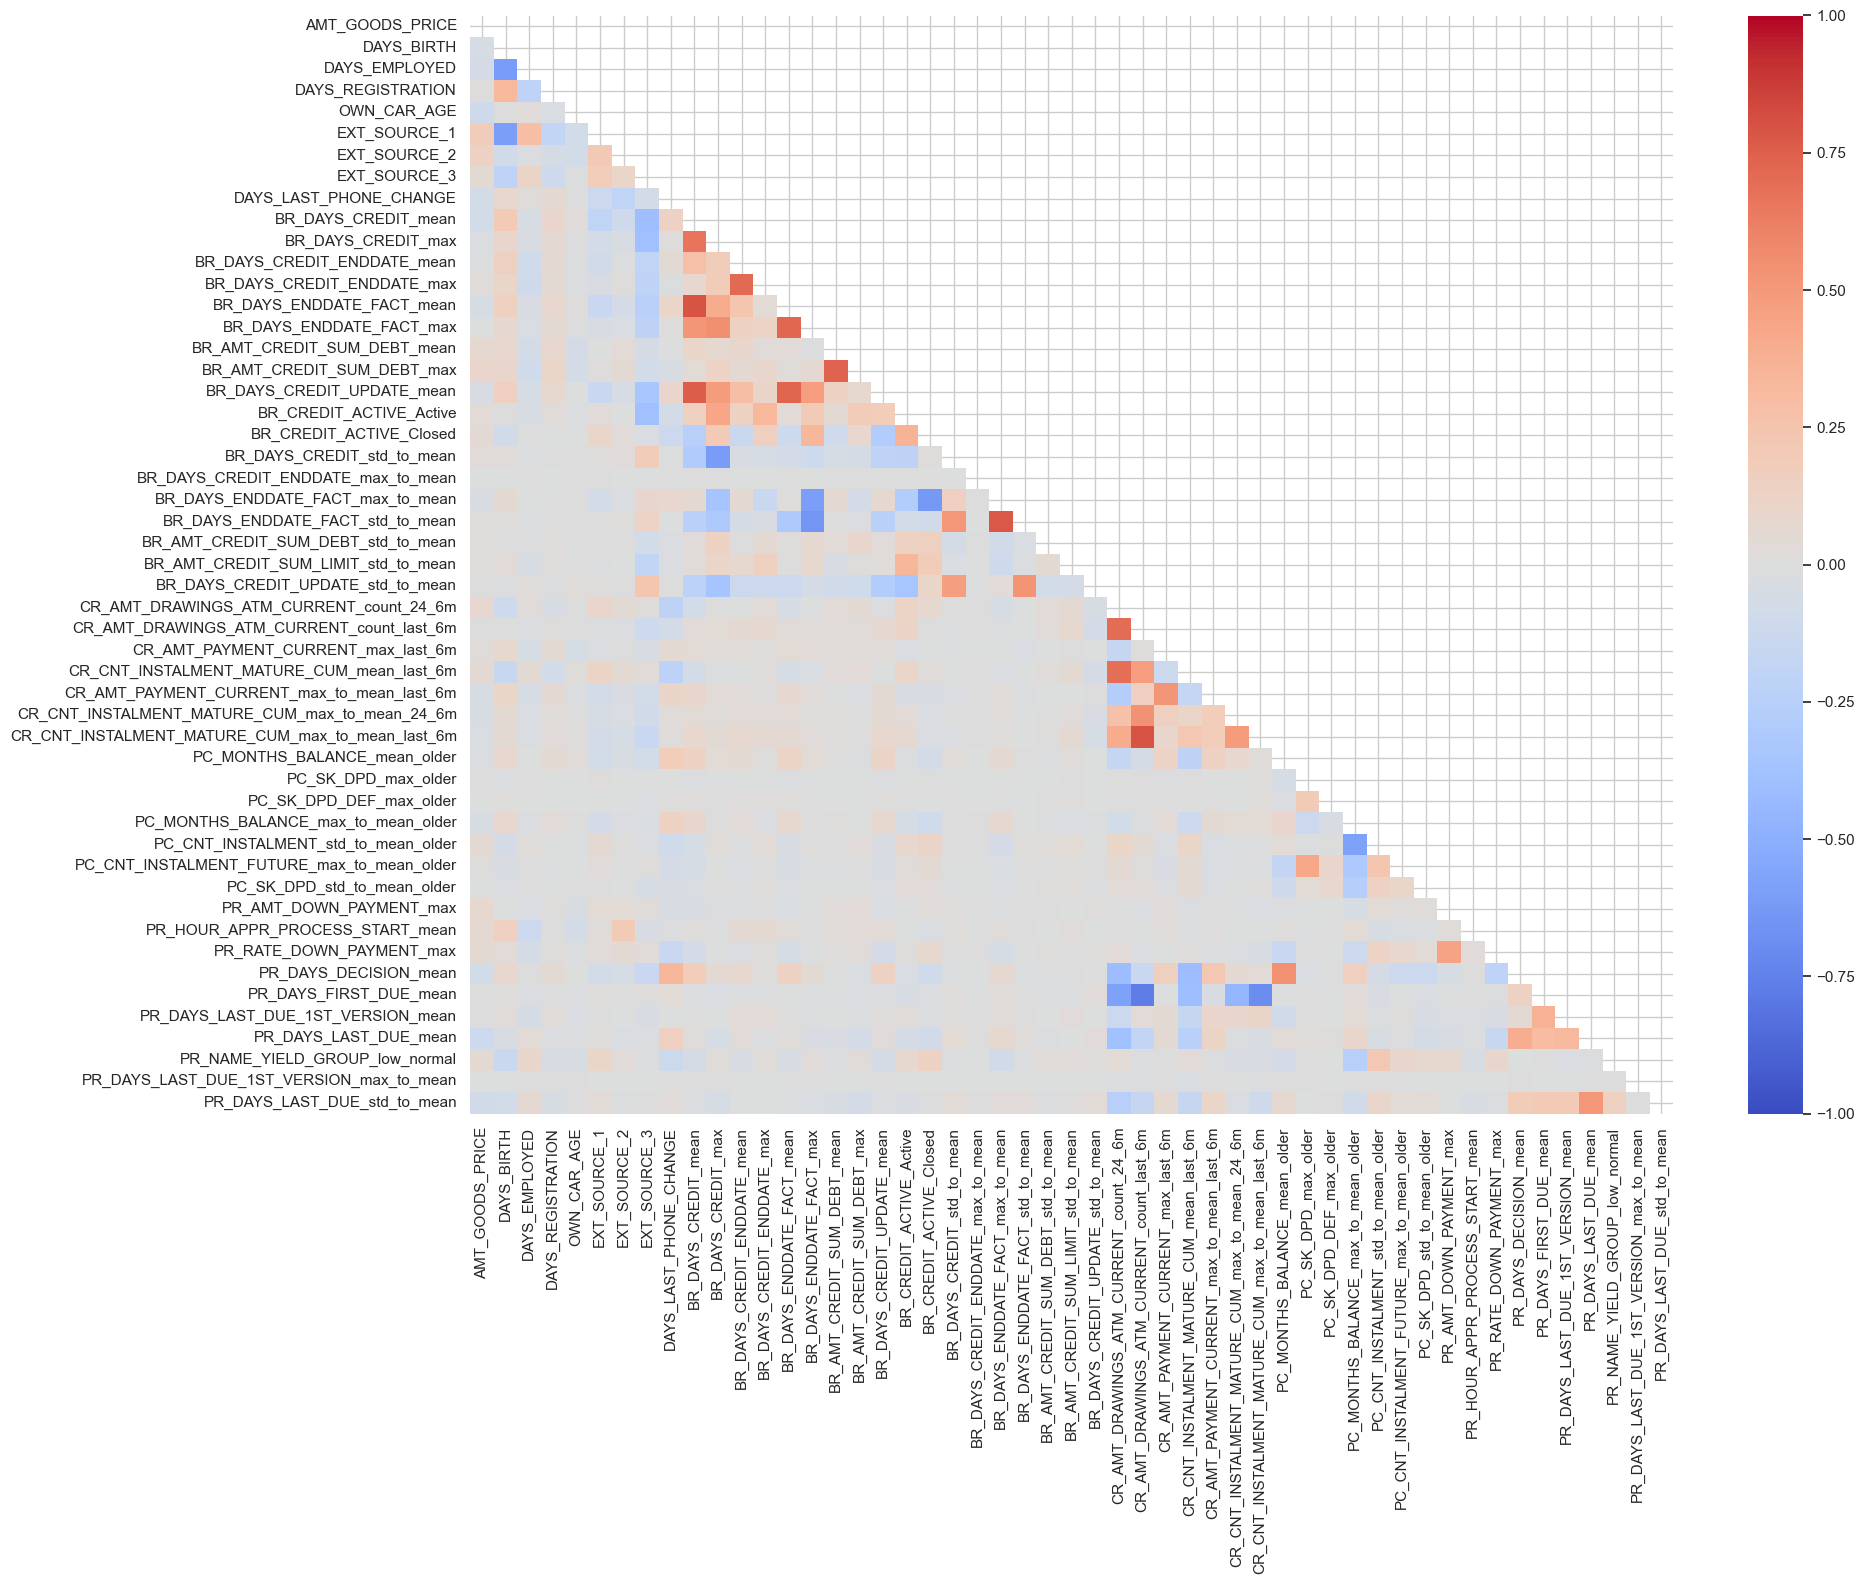

In [9]:
new_corr = final.drop(["TARGET", "SK_ID_CURR"], axis=1).select_dtypes(include="number").corr()
mask = np.triu(np.ones_like(new_corr, dtype=bool))
plt.figure(figsize=(20, 16))
sns.heatmap(new_corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

In [10]:
# on the remaining features we can apply Boruta to select the top N_FEATURES_TO_SELECT features, this will be our final set of features for modeling
# we do that on a subset of the data to speed it up
X = pd.get_dummies(final.drop(["TARGET", "SK_ID_CURR"], axis=1))
feature_names = X.columns
X = X.fillna(-99999999)
y = final["TARGET"].values

In [11]:
rf = RandomForestClassifier(
    n_jobs=-1,
    class_weight="balanced",
    max_depth=8,
    random_state=RANDOM_SEED
)
# subsample 20,000 rows - we run it twice with different random states to get a more robust set of features, we will take the intersection of the two sets of confirmed features
X_sample, y_sample = resample(X, y, n_samples=20000, random_state=RANDOM_SEED, stratify=y)
boruta = BorutaPy(
    estimator=rf,
    n_estimators="auto",
    max_iter=50,
    random_state=RANDOM_SEED
)
boruta.fit(X_sample.values, y_sample)
confirmed = feature_names[boruta.support_].tolist()
tentative = feature_names[boruta.support_weak_].tolist()
print(f"Confirmed: {len(confirmed)} features")
print(confirmed)
print(f"\nTentative: {len(tentative)} features")
print(tentative)
X_sample_2, y_sample_2 = resample(X, y, n_samples=20000, random_state=RANDOM_SEED + 1, stratify=y)
boruta_2 = BorutaPy(
    estimator=rf,
    n_estimators="auto",
    max_iter=50,
    random_state=RANDOM_SEED
)
boruta_2.fit(X_sample_2.values, y_sample_2)
confirmed_2 = feature_names[boruta_2.support_].tolist()
tentative_2 = feature_names[boruta_2.support_weak_].tolist()
print(f"Confirmed: {len(confirmed_2)} features")
print(confirmed_2)
print(f"\nTentative: {len(tentative_2)} features")
print(tentative_2)

Confirmed: 22 features
['AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_LAST_PHONE_CHANGE', 'BR_DAYS_CREDIT_mean', 'BR_DAYS_CREDIT_max', 'BR_DAYS_CREDIT_ENDDATE_mean', 'BR_DAYS_ENDDATE_FACT_mean', 'BR_DAYS_CREDIT_UPDATE_mean', 'BR_DAYS_CREDIT_std_to_mean', 'BR_DAYS_CREDIT_ENDDATE_max_to_mean', 'PR_HOUR_APPR_PROCESS_START_mean', 'PR_RATE_DOWN_PAYMENT_max', 'PR_DAYS_DECISION_mean', 'PR_DAYS_FIRST_DUE_mean', 'PR_DAYS_LAST_DUE_1ST_VERSION_mean', 'PR_DAYS_LAST_DUE_mean', 'PR_DAYS_LAST_DUE_1ST_VERSION_max_to_mean']

Tentative: 0 features
[]
Confirmed: 18 features
['AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_LAST_PHONE_CHANGE', 'BR_DAYS_CREDIT_mean', 'BR_DAYS_CREDIT_max', 'BR_DAYS_CREDIT_ENDDATE_mean', 'BR_DAYS_CREDIT_ENDDATE_max', 'BR_DAYS_CREDIT_UPDATE_mean', 'BR_DAYS_CREDIT_std_to_mean', 'BR_DAYS_CREDIT_UPDATE_std_to_mean', 'PR_AMT_DO

In [12]:
set1 = set(confirmed + tentative)
set2 = set(confirmed_2 + tentative_2)
only_in_first = set1 - set2
only_in_second = set2 - set1
print(f"Only in first run: {only_in_first}")
print(f"Only in second run: {only_in_second}")
print(f"\nIn both: {len(set1 & set2)} features")

Only in first run: {'PR_HOUR_APPR_PROCESS_START_mean', 'PR_DAYS_LAST_DUE_1ST_VERSION_max_to_mean', 'PR_DAYS_LAST_DUE_mean', 'BR_DAYS_ENDDATE_FACT_mean', 'PR_DAYS_FIRST_DUE_mean', 'PR_RATE_DOWN_PAYMENT_max', 'BR_DAYS_CREDIT_ENDDATE_max_to_mean'}
Only in second run: {'BR_DAYS_CREDIT_UPDATE_std_to_mean', 'BR_AMT_CREDIT_SUM_DEBT_mean', 'PR_AMT_DOWN_PAYMENT_max', 'BR_DAYS_CREDIT_ENDDATE_max'}

In both: 15 features


In [13]:
final_features = list(set(confirmed + tentative + confirmed_2 + tentative_2))
print(f"{len(final_features)} features selected")
print(final_features)

26 features selected
['EXT_SOURCE_3', 'BR_DAYS_CREDIT_mean', 'EXT_SOURCE_1', 'PR_AMT_DOWN_PAYMENT_max', 'DAYS_LAST_PHONE_CHANGE', 'AMT_GOODS_PRICE', 'BR_DAYS_CREDIT_max', 'BR_DAYS_CREDIT_UPDATE_std_to_mean', 'BR_AMT_CREDIT_SUM_DEBT_mean', 'PR_DAYS_LAST_DUE_1ST_VERSION_mean', 'PR_DAYS_FIRST_DUE_mean', 'PR_RATE_DOWN_PAYMENT_max', 'BR_DAYS_CREDIT_UPDATE_mean', 'BR_DAYS_CREDIT_ENDDATE_max_to_mean', 'EXT_SOURCE_2', 'DAYS_EMPLOYED', 'BR_DAYS_ENDDATE_FACT_mean', 'PR_DAYS_LAST_DUE_mean', 'BR_DAYS_CREDIT_std_to_mean', 'DAYS_BIRTH', 'BR_DAYS_CREDIT_ENDDATE_mean', 'PR_HOUR_APPR_PROCESS_START_mean', 'PR_DAYS_LAST_DUE_1ST_VERSION_max_to_mean', 'PR_DAYS_DECISION_mean', 'BR_DAYS_CREDIT_ENDDATE_max', 'DAYS_REGISTRATION']


In [14]:
ranking_df = pd.DataFrame({
    "feature": feature_names,
    "rank_1": boruta.ranking_,
    "rank_2": boruta_2.ranking_
})

ranking_df = ranking_df[ranking_df["feature"].isin(final_features)]
ranking_df["avg_rank"] = (ranking_df["rank_1"] + ranking_df["rank_2"]) / 2
ranking_df = ranking_df.sort_values("avg_rank")

print(ranking_df)

                                     feature  rank_1  rank_2  avg_rank
0                            AMT_GOODS_PRICE       1       1       1.0
1                                 DAYS_BIRTH       1       1       1.0
2                              DAYS_EMPLOYED       1       1       1.0
3                          DAYS_REGISTRATION       1       1       1.0
5                               EXT_SOURCE_1       1       1       1.0
6                               EXT_SOURCE_2       1       1       1.0
7                               EXT_SOURCE_3       1       1       1.0
8                     DAYS_LAST_PHONE_CHANGE       1       1       1.0
9                        BR_DAYS_CREDIT_mean       1       1       1.0
10                        BR_DAYS_CREDIT_max       1       1       1.0
11               BR_DAYS_CREDIT_ENDDATE_mean       1       1       1.0
20                BR_DAYS_CREDIT_std_to_mean       1       1       1.0
17                BR_DAYS_CREDIT_UPDATE_mean       1       1       1.0
46    

In [15]:
l = ["AMT_GOODS_PRICE",
      "DAYS_BIRTH",   
      "DAYS_EMPLOYED", 
      "EXT_SOURCE_1",       
      "EXT_SOURCE_2",       
      "EXT_SOURCE_3",      
      "DAYS_LAST_PHONE_CHANGE",      
      "BR_DAYS_CREDIT_mean",      
      "BR_DAYS_CREDIT_max",      
      "BR_DAYS_CREDIT_ENDDATE_mean",   
      "BR_DAYS_CREDIT_std_to_mean",     
      "BR_DAYS_CREDIT_UPDATE_mean",     
      "PR_DAYS_LAST_DUE_1ST_VERSION_mean",
      "PR_DAYS_DECISION_mean",
      "BR_DAYS_CREDIT_ENDDATE_max", 
      "BR_DAYS_CREDIT_UPDATE_std_to_mean", 
      "PR_DAYS_FIRST_DUE_mean",     
      "PR_AMT_DOWN_PAYMENT_max",
      "BR_AMT_CREDIT_SUM_DEBT_mean",
      "BR_DAYS_ENDDATE_FACT_mean"
        ]

In [17]:
final = final[l + ["TARGET", "SK_ID_CURR"]]

In [18]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   AMT_GOODS_PRICE                    307233 non-null  float64
 1   DAYS_BIRTH                         307511 non-null  int64  
 2   DAYS_EMPLOYED                      307511 non-null  int64  
 3   EXT_SOURCE_1                       134133 non-null  float64
 4   EXT_SOURCE_2                       306851 non-null  float64
 5   EXT_SOURCE_3                       246546 non-null  float64
 6   DAYS_LAST_PHONE_CHANGE             307510 non-null  float64
 7   BR_DAYS_CREDIT_mean                263457 non-null  float64
 8   BR_DAYS_CREDIT_max                 263457 non-null  float64
 9   BR_DAYS_CREDIT_ENDDATE_mean        261208 non-null  float64
 10  BR_DAYS_CREDIT_std_to_mean         227347 non-null  float64
 11  BR_DAYS_CREDIT_UPDATE_mean         2634

In [22]:
final.columns

Index(['AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_LAST_PHONE_CHANGE',
       'BR_DAYS_CREDIT_mean', 'BR_DAYS_CREDIT_max',
       'BR_DAYS_CREDIT_ENDDATE_mean', 'BR_DAYS_CREDIT_std_to_mean',
       'BR_DAYS_CREDIT_UPDATE_mean', 'PR_DAYS_LAST_DUE_1ST_VERSION_mean',
       'PR_DAYS_DECISION_mean', 'BR_DAYS_CREDIT_ENDDATE_max',
       'BR_DAYS_CREDIT_UPDATE_std_to_mean', 'PR_DAYS_FIRST_DUE_mean',
       'PR_AMT_DOWN_PAYMENT_max', 'BR_AMT_CREDIT_SUM_DEBT_mean',
       'BR_DAYS_ENDDATE_FACT_mean', 'TARGET', 'SK_ID_CURR'],
      dtype='object')

In [20]:
final.to_csv(DATA_DIR / "FINAL_FINAL_phone_buckets_6_24_after_selection.csv", index=False)

In [95]:
#TODO TODO TODO TODO

Dictionary: BR - from bureau dataset; PR - previous_application dataset; PC - POS_CASH_balance dataset
- AMT_GOODS_PRICE -> should be positivel correlated with TARGET (the bigger the loan the bigger the risk), however the risk part plays another role here - higher approval standards may lower the risk for higher loans, therefore we observe a complex relation with TARGET
- DAYS_BIRTH -> probably an auxiliary variable - makes more sense in the context of other variables 
- DAYS_EMPLOYED -> longer employment - more stable client
- EXT_SOURCE_1 -> we assume its some kind of a score from other credit institution, therefore we should be cautious with using such features in our model - it has a very strong impact on our predictions but it is indeed a 'black box' 
- EXT_SOURCE_2 -> see EXT_SOURCE_1
- EXT_SOURCE_3 -> see EXT_SOURCE_1
- DAYS_LATS_PHONE_CHANGE -> how many days before application did client change phone
- BR_DAYS_CREDIT_mean -> mean of how many days before current application did client apply for Credit Bureau credits - the idea is that if this number is close to zero it means that the client may have applied for other credits, which is possibly an unfavorable situation (stacking credits - stacking payments - higher default risk)
- BR_DAYS_CREDIT_max -> similar to the above 
- BR_DAYS_CREDIT_ENDDATE_mean -> mean of remaining durations of CB credit
- BR_DAYS_CREDIT_std_to_mean -> std / mean of how many days before current application did client apply for Credit Bureau credits
- BR_DAYS_CREDIT_UPDATE_mean -> similar to DAYS_CREDIT
- PR_DAYS_LAST_DUE_1ST_VERSION_mean -> mean of the relative to application date of current application when were the first due of the previous applications
- PR_DAYS_DECISION_mean -> relative to current application when was the decision about previous application made
- BR_DAYS_CREDIT_ENDDATE_max -> another statistic for DAYS_CREDIT_ENDDATE
- BR_DAYS_CREDIT_UPDATE_std_to_mean -> another statistic for DAYS_CREDIT_UPDATE
- PR_DAYS_FIRST_DUE_mean -> mean of relative to application date of current application when was the first due supposed to be of the previous applications
- PR_AMT_DOWN_PAYMENT_max -> mean of down payment on the previous applications
- BR_AMT_CREDIT_SUM_DEBT_mean -> mean of current debts on Credit Bureau credit
- BR_DAYS_ENDDATE_FACT_mean -> mean of the days since CB credits ended at the time of application in Home Credit (only for closed credit)

## 5. Model Training

Train a tree-based classifier. LightGBM is recommended, but you may also
try XGBoost or CatBoost.

**Important:** Use `RANDOM_SEED = 42` for all random operations.

In [2]:
final = pd.read_csv(DATA_DIR / "FINAL.csv")

In [3]:
ratio = len(final[final[TARGET_COLUMN] == 0]) / len(final[final[TARGET_COLUMN] == 1])

for col in final.select_dtypes(include='object').columns:
    final[col] = final[col].astype('category')
X = final.drop(columns=[TARGET_COLUMN, 'SK_ID_CURR'])
y = final[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

In [4]:
def objective(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",

        "n_estimators": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.13, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

        "subsample": trial.suggest_float("subsample", 0.3, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1),

        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 3),

        "tree_method": "hist"
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    aucs = []

    for train_idx, valid_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = XGBClassifier(
            **params,
            enable_categorical=True,
            early_stopping_rounds=50,
            scale_pos_weight=ratio
        )

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        aucs.append(model.best_score)

    return np.mean(aucs)

In [7]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)  
)

study.optimize(objective, n_trials=50)

[I 2026-04-24 13:44:03,744] A new study created in memory with name: no-name-de8660ac-f01e-4404-a653-726eb0138400
[I 2026-04-24 13:44:55,370] Trial 0 finished with value: 0.747783423935853 and parameters: {'learning_rate': 0.05195611612871557, 'max_depth': 8, 'min_child_weight': 8, 'subsample': 0.7190609389379257, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'reg_lambda': 1.5227525095137953, 'reg_alpha': 2.5985284373248057}. Best is trial 0 with value: 0.747783423935853.
[I 2026-04-24 13:45:33,566] Trial 1 finished with value: 0.7479744805545914 and parameters: {'learning_rate': 0.07243101603938996, 'max_depth': 7, 'min_child_weight': 1, 'subsample': 0.978936896513396, 'colsample_bytree': 0.9329770563201687, 'gamma': 1.0616955533913808, 'reg_lambda': 2.636424704863906, 'reg_alpha': 0.5502135295603015}. Best is trial 1 with value: 0.7479744805545914.
[I 2026-04-24 13:46:30,144] Trial 2 finished with value: 0.7513322327797501 and parameters: {'learning_rate': 0.04

In [8]:
best_params = study.best_params
model = XGBClassifier(
    enable_categorical=True,
    **best_params,
    n_estimators=2000,
    tree_method="hist",
    scale_pos_weight=ratio
)

with open(MODELS_DIR / "model_FINAL.pkl", "wb") as f:
    pickle.dump(model, f)
    

In [2]:
final = pd.read_csv(DATA_DIR / "FINAL.csv")

In [3]:
ratio = len(final[final[TARGET_COLUMN] == 0]) / len(final[final[TARGET_COLUMN] == 1])

for col in final.select_dtypes(include='object').columns:
    final[col] = final[col].astype('category')
X = final.drop(columns=[TARGET_COLUMN, 'SK_ID_CURR'])
y = final[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

In [4]:
with open(MODELS_DIR / "model_FINAL.pkl", "rb") as f:
    model = pickle.load(f)

In [5]:
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7911135953639263
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [7]:
def plot_auc(model, X_test, y_test):
    # generic AUC plotting function 
    test_proba = model.predict_proba(X_test)[:, 1]
    test_pred = model.predict(X_test)
    print("AUC score:", np.round(roc_auc_score(y_test, test_proba), 3))
    fpr, tpr, _ = roc_curve(y_test, test_proba)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, test_proba):.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title("ROC curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    plt.tight_layout()
    plt.show()

AUC score: 0.755


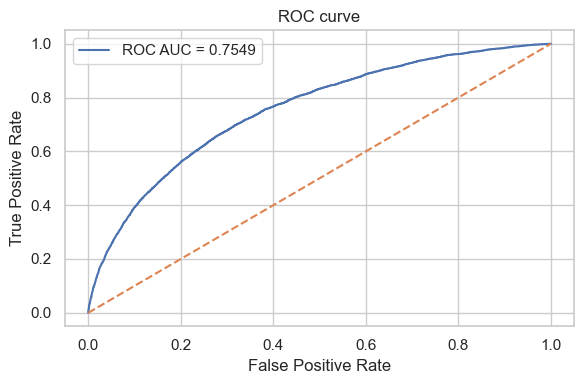

In [8]:
plot_auc(model, X_test, y_test)

In [6]:
with open(MODELS_DIR / "model_FINAL_calibrated.pkl", "rb") as f:
    calibrated = pickle.load(f)

In [7]:
#calibrated = CalibratedClassifierCV(model, method="isotonic", cv=5)
calibrated.fit(X_train, y_train)
proba_cal = calibrated.predict_proba(X_test)[:, 1]

Brier raw: 0.19042712921023622
Brier calibrated: 0.0678587666028925


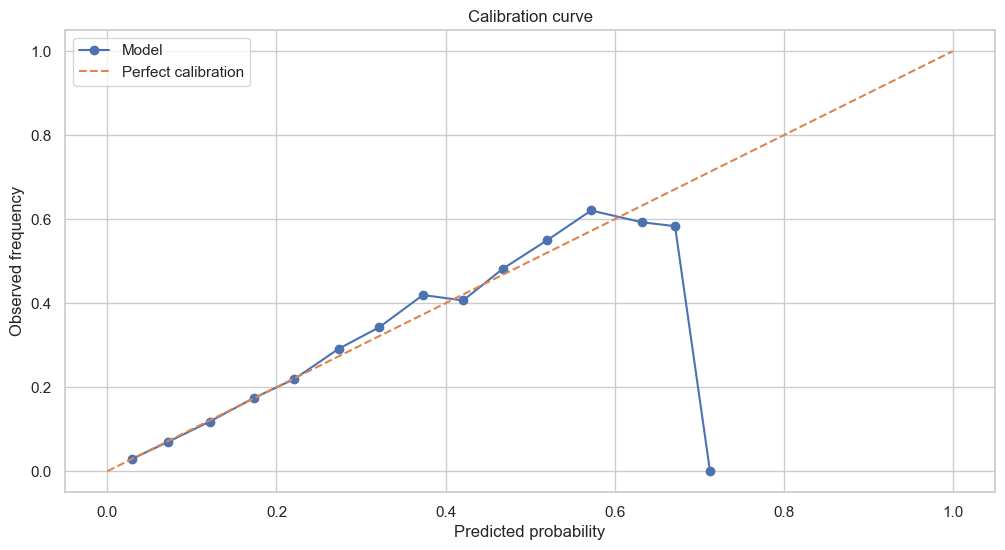

In [8]:
proba_raw = model.predict_proba(X_test)[:, 1]

print("Brier raw:", brier_score_loss(y_test, proba_raw))
print("Brier calibrated:", brier_score_loss(y_test, proba_cal))

prob_true, prob_pred = calibration_curve(y_test, proba_cal, n_bins=20)

plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.legend()
plt.title("Calibration curve")
plt.show()

In [9]:
thresholds = np.linspace(0, 1, 100)
scores = [f1_score(y_test, proba_cal >= t) for t in thresholds]
best_t = thresholds[np.argmax(scores)]
print("Best threshold:", best_t)

Best threshold: 0.15151515151515152


In [10]:
masterscale = pd.DataFrame({
    "Rating": [
        "AAA", "AA+", "AA", "AA-",
        "A+", "A", "A-",
        "BBB+", "BBB", "BBB-",
        "BB+", "BB", "BB-",
        "B+", "B", "B-",
        "CCC", "CC", "C", "D",
    ],
    "PD_lower": [
        0.0000, 0.0002, 0.0004, 0.0008,
        0.0015, 0.0025, 0.0040,
        0.0060, 0.0100, 0.0150,
        0.0250, 0.0400, 0.0600,
        0.1000, 0.1500, 0.2000,
        0.3000, 0.4000, 0.5000, 0.7000,
    ],
    "PD_upper": [
        0.0002, 0.0004, 0.0008, 0.0015,
        0.0025, 0.0040, 0.0060,
        0.0100, 0.0150, 0.0250,
        0.0400, 0.0600, 0.1000,
        0.1500, 0.2000, 0.3000,
        0.4000, 0.5000, 0.7000, 1.0000,
    ],
})
def assign_rating(pd_value, masterscale):
    row = masterscale[
        (masterscale["PD_lower"] <= pd_value) & (pd_value < masterscale["PD_upper"])
    ]
    if len(row) == 0:
        return None
    return row["Rating"].values[0]
ratings = [assign_rating(p, masterscale) for p in proba_cal]
ratings = pd.Series(ratings)
threshold = best_t
print("PD threshold:", threshold)
# classify
y_pred_default = (proba_cal >= threshold).astype(int)
print("Default rate:", y_pred_default.mean())

PD threshold: 0.15151515151515152
Default rate: 0.14171666422776125


In [11]:
def plot_other(y_test, y_pred_default, proba_cal):
    print("Precision score:", np.round(precision_score(y_test, y_pred_default, pos_label=1), 3))
    print("Recall score:", np.round(recall_score(y_test, y_pred_default, pos_label=1), 3))
    print("AUC score:", np.round(roc_auc_score(y_test, proba_cal), 3))
    precision, recall, _ = precision_recall_curve(y_test, proba_cal)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(recall, precision, label=f"AP = {average_precision_score(y_test, proba_cal):.4f}")
    ax.set_title("Precision-Recall curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    ConfusionMatrixDisplay.from_predictions(y_test,y_pred_default)

Precision score: 0.242
Recall score: 0.425
AUC score: 0.755


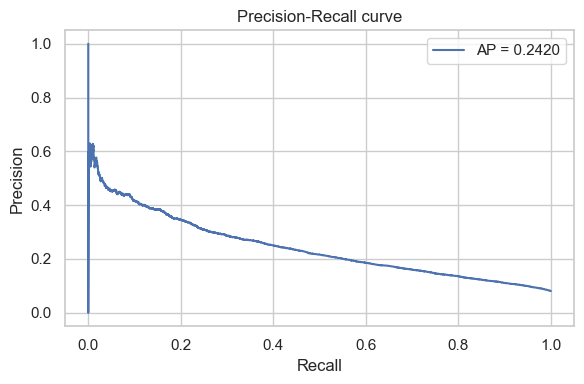

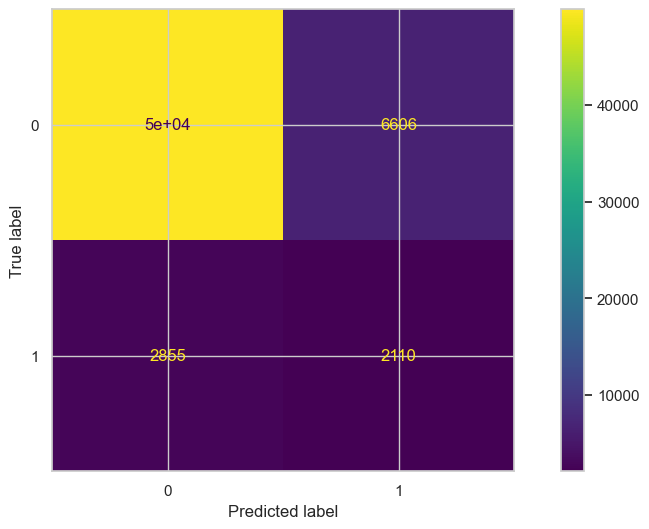

In [12]:
plot_other(y_test, y_pred_default, proba_cal) 

In [11]:
decision_row = masterscale[
    (masterscale["PD_lower"] <= threshold) & (threshold < masterscale["PD_upper"])
]

decision_rating = decision_row["Rating"].values[0]
decision_threshold = decision_row["PD_upper"].values[0]

print("Decision rating boundary:", decision_rating)
print("Use PD >=", decision_threshold, "as default cutoff")

Decision rating boundary: B
Use PD >= 0.2 as default cutoff


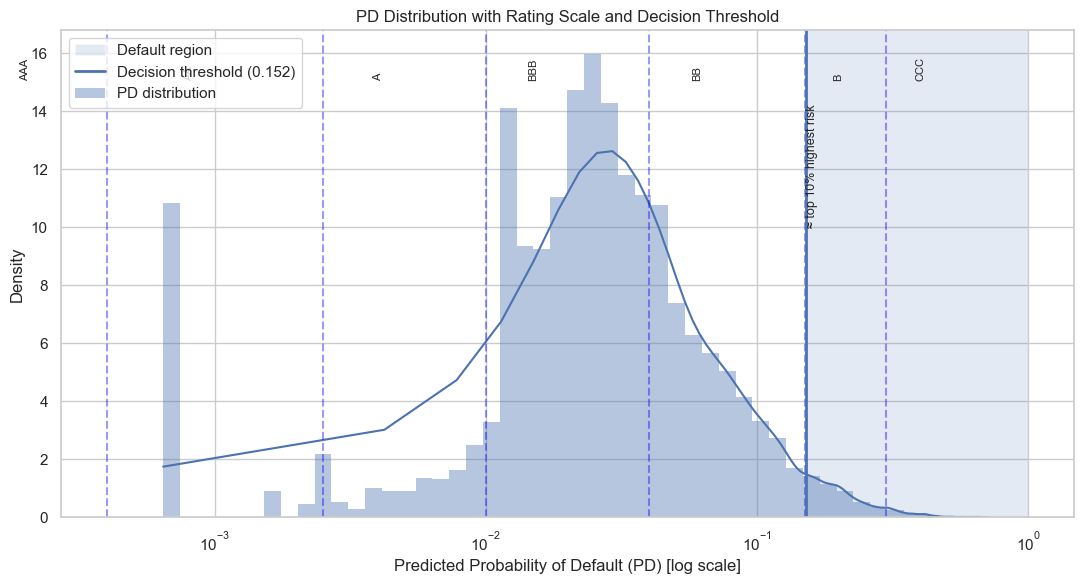

In [14]:
plt.figure(figsize=(11,6))
eps = 1e-6
pd_safe = np.clip(proba_cal, eps, 1)
sns.set_style("whitegrid")
bins = np.logspace(np.log10(pd_safe.min()), np.log10(pd_safe.max()), 50)
sns.histplot(
    pd_safe,
    bins=bins,
    kde=True,
    stat="density",
    alpha=0.4,
    label="PD distribution"
)
plt.xscale("log")
key_ratings = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]
for _, row in masterscale.iterrows():
    if row["Rating"] in key_ratings and row["PD_upper"] > 0:
        plt.axvline(row["PD_lower"], linestyle="--", alpha=0.4, color="blue")
        
        plt.text(
            row["PD_upper"],
            plt.ylim()[1]*0.9,
            row["Rating"],
            rotation=90,
            fontsize=8,
            ha="center"
        )
plt.axvspan(threshold, 1, alpha=0.15, label="Default region")
plt.axvline(
    threshold,
    linewidth=2,
    linestyle="-",
    label=f"Decision threshold ({threshold:.3f})"
)
plt.xlabel("Predicted Probability of Default (PD) [log scale]")
plt.ylabel("Density")
plt.title("PD Distribution with Rating Scale and Decision Threshold")
plt.text(
    threshold,
    plt.ylim()[1]*0.6,
    "≈ top 10% highest risk",
    rotation=90,
    fontsize=9,
    ha="left"
)
plt.legend()
plt.tight_layout()
plt.show()

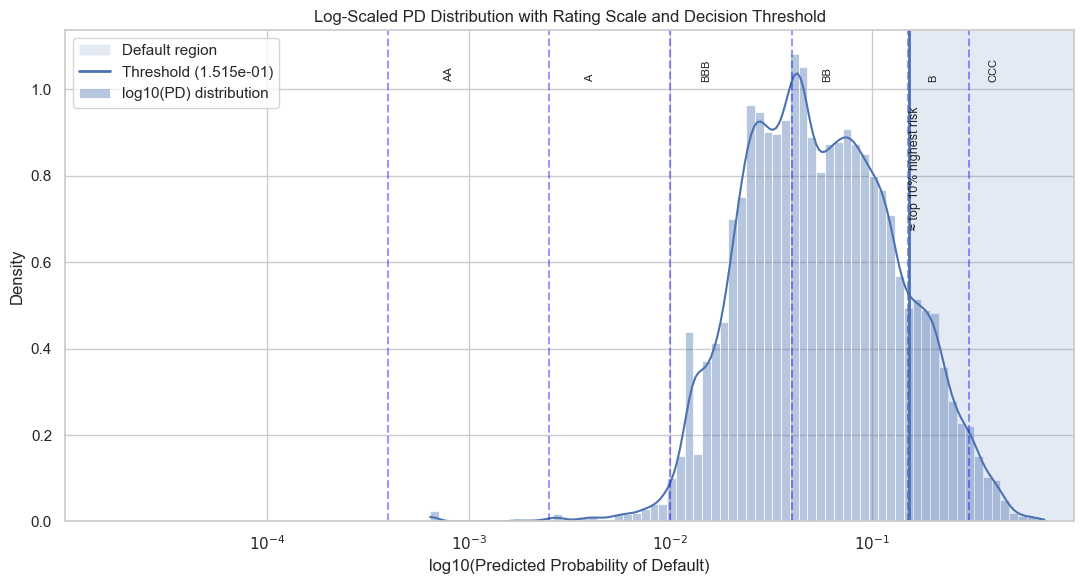

In [15]:
plt.figure(figsize=(11, 6))
eps = 1e-12
pd_safe = np.clip(proba_cal, eps, 1)
log_pd = np.log10(pd_safe)
log_threshold = np.log10(threshold)
xticks = np.arange(np.floor(log_pd.min()), 0)
plt.xticks(xticks, [f"$10^{{{int(x)}}}$" for x in xticks])
sns.set_style("whitegrid")
plt.xlim(-5, 0) 
sns.histplot(
    log_pd,
    bins=70,
    kde=True,
    stat="density",
    alpha=0.4,
    label="log10(PD) distribution"
)
key_ratings = [ "AA", "A", "BBB", "BB", "B", "CCC"]
for _, row in masterscale.iterrows():
    if row["Rating"] in key_ratings and row["PD_lower"] > 0:
        log_lower = np.log10(max(row["PD_lower"], eps))
        log_upper = np.log10(max(row["PD_upper"], eps))

        plt.axvline(log_lower, linestyle="--", alpha=0.4, color="blue")

        plt.text(
            log_upper,
            plt.ylim()[1] * 0.9,
            row["Rating"],
            rotation=90,
            fontsize=8,
            ha="center"
        )
plt.axvspan(log_threshold, 0, alpha=0.15, label="Default region")
plt.axvline(
    log_threshold,
    linewidth=2,
    linestyle="-",
    label=f"Threshold ({threshold:.3e})"
)
plt.xlabel("log10(Predicted Probability of Default)")
plt.ylabel("Density")
plt.title("Log-Scaled PD Distribution with Rating Scale and Decision Threshold")
plt.text(
    log_threshold,
    plt.ylim()[1] * 0.6,
    "≈ top 10% highest risk",
    rotation=90,
    fontsize=9,
    ha="left"
)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Plot SHAP summary plot

Provide a quick discussion how model works "globally"

In [23]:
importance = model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values(by='importance', ascending=False)

importance_df

,feature,importance
5,EXT_SOURCE_3,270.563477
4,EXT_SOURCE_2,255.092758
3,EXT_SOURCE_1,115.034294
1,DAYS_BIRTH,77.352142
0,AMT_GOODS_PRICE,72.579559
2,DAYS_EMPLOYED,70.954292
17,PR_AMT_DOWN_PAYMENT_max,63.438320
7,BR_DAYS_CREDIT_mean,60.088902
12,PR_DAYS_LAST_DUE_1ST_VERSION_mean,56.629791
18,BR_AMT_CREDIT_SUM_DEBT_mean,56.326744


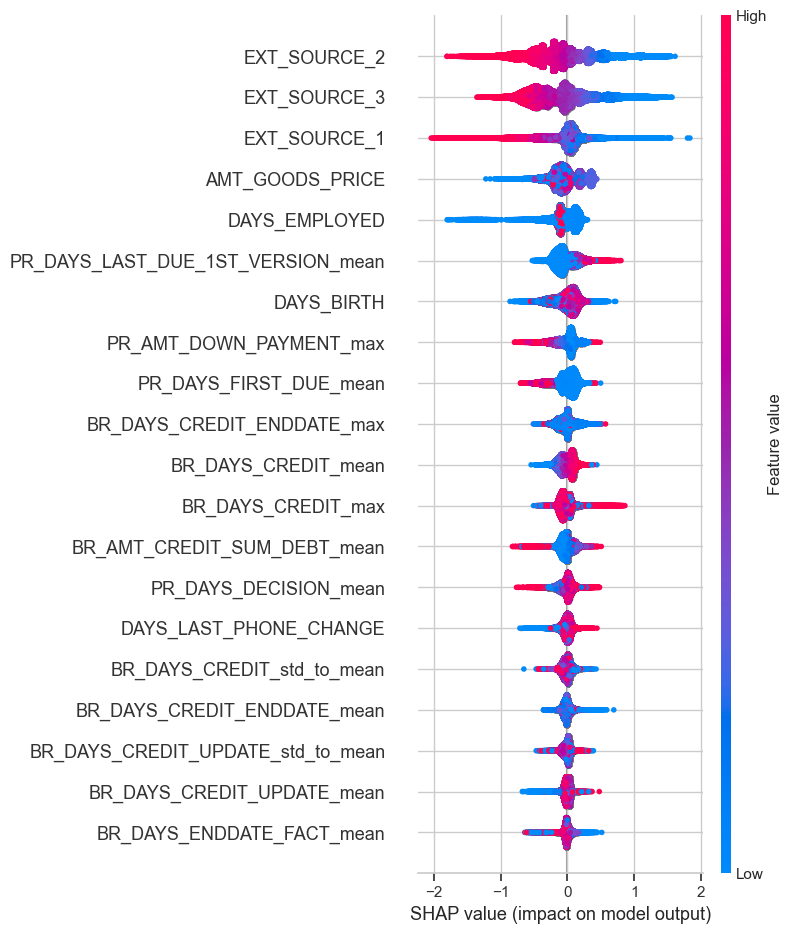

In [24]:
import shap
explainer = shap.TreeExplainer(model) 
shap_values = explainer.shap_values(X_train, approximate=True) 
shap.summary_plot(shap_values, X_train, max_display=20)

## 7. Counterfactual Analysis

### 7a. Select Interesting Test Examples

Choose 10–15 instances from the test set that are interesting for CE analysis:
- Near the decision boundary
- Correctly classified defaults
- Misclassified examples
- High-confidence edge cases

Dictionary: BR - from bureau dataset; PR - previous_application dataset; PC - POS_CASH_balance dataset
- AMT_GOODS_PRICE -> should be positivel correlated with TARGET (the bigger the loan the bigger the risk), however the risk part plays another role here - higher approval standards may lower the risk for higher loans, therefore we observe a complex relation with TARGET
- DAYS_BIRTH -> probably an auxiliary variable - makes more sense in the context of other variables 
- DAYS_EMPLOYED -> longer employment - more stable client
- EXT_SOURCE_1 -> we assume its some kind of a score from other credit institution, therefore we should be cautious with using such features in our model - it has a very strong impact on our predictions but it is indeed a 'black box' 
- EXT_SOURCE_2 -> see EXT_SOURCE_1
- EXT_SOURCE_3 -> see EXT_SOURCE_1
- DAYS_LATS_PHONE_CHANGE -> how many days before application did client change phone
- BR_DAYS_CREDIT_mean -> mean of how many days before current application did client apply for Credit Bureau credits - the idea is that if this number is close to zero it means that the client may have applied for other credits, which is possibly an unfavorable situation (stacking credits - stacking payments - higher default risk)
- BR_DAYS_CREDIT_max -> similar to the above 
- BR_DAYS_CREDIT_ENDDATE_mean -> mean of remaining durations of CB credit
- BR_DAYS_CREDIT_std_to_mean -> std / mean of how many days before current application did client apply for Credit Bureau credits
- BR_DAYS_CREDIT_UPDATE_mean -> similar to DAYS_CREDIT
- PR_DAYS_LAST_DUE_1ST_VERSION_mean -> mean of the relative to application date of current application when were the first due of the previous applications
- PR_DAYS_DECISION_mean -> relative to current application when was the decision about previous application made
- BR_DAYS_CREDIT_ENDDATE_max -> another statistic for DAYS_CREDIT_ENDDATE
- BR_DAYS_CREDIT_UPDATE_std_to_mean -> another statistic for DAYS_CREDIT_UPDATE
- PR_DAYS_FIRST_DUE_mean -> mean of relative to application date of current application when was the first due supposed to be of the previous applications
- PR_AMT_DOWN_PAYMENT_max -> mean of down payment on the previous applications
- BR_AMT_CREDIT_SUM_DEBT_mean -> mean of current debts on Credit Bureau credit
- BR_DAYS_ENDDATE_FACT_mean -> mean of the days since CB credits ended at the time of application in Home Credit (only for closed credit)

In [ ]:
# TODO: Select interesting examples based on prediction probability

interesting_examples = None

### 7b. DiCE — Diverse Counterfactual Explanations

Generate counterfactuals using the DiCE package.

Documentation: [github.com/interpretml/DiCE](https://github.com/interpretml/DiCE)

In [ ]:
# TODO: Implement DiCE counterfactual generation

In [78]:
X_train_clean = X_train.dropna()
X_train_clean[TARGET_COLUMN] = y_train.loc[X_train_clean.index]
continuous_features = X_train.select_dtypes(
    include=['float64', 'float32', 'int64', 'int32']
).columns.tolist()
d = dice_ml.Data(
    dataframe=X_train_clean,
    continuous_features=continuous_features,
    outcome_name='TARGET'
)
m = dice_ml.Model(model=calibrated, backend='sklearn')
exp = Dice(d, m, method='random')
clean = X_test.dropna()
probs = calibrated.predict_proba(clean)[:, 1]
idx = np.argsort(np.abs(probs - 0.5))[0:20]
query = clean.iloc[idx]
print("Query probability of class 1:", probs[idx])
np.random.seed(RANDOM_SEED)
features_to_vary = ['AMT_GOODS_PRICE', 'DAYS_EMPLOYED', 'DAYS_LAST_PHONE_CHANGE', 'BR_DAYS_CREDIT_mean', 'BR_DAYS_CREDIT_ENDDATE_mean', 'BR_DAYS_CREDIT_UPDATE_mean', 'PR_DAYS_LAST_DUE_1ST_VERSION_mean', 'PR_DAYS_DECISION_mean']
cf = exp.generate_counterfactuals(
    query,
    total_CFs=4,
    desired_class="opposite",
    features_to_vary=features_to_vary
)
cf.visualize_as_dataframe(show_only_changes=True)

Query probability of class 1: [0.49387715 0.50641444 0.49291431 0.50922974 0.50952556 0.51008496
 0.51008496 0.48281197 0.48111491 0.52036566 0.47872894 0.52204558
 0.47454675 0.47377118 0.46325189 0.46241421 0.45976368 0.45516247
 0.45456416 0.54925259]


100%|██████████| 20/20 [02:52<00:00,  8.61s/it]

Query instance (original outcome : 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,373500.0,-11941,-811,0.085281,0.047225,0.168416,0.0,-1198.75,-55.0,-1028.0,...,-399.75,-386.333344,-641.0,-24.0,-0.993855,-776.333313,8100.0,0.0,-1059.0,0



Diverse Counterfactual set (new outcome: 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-,-,-,...,-,132111.1,-836.4,-,-,-,-,-,-,1.0
1,-,-,242051.0,-,-,-,-,-,-,-,...,-,-,-87.9,-,-,-,-,-,-,1.0
2,-,-,128819.0,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
3,-,-,-,-,-,-,-,-,-,-,...,-,182410.3,-975.5,-,-,-,-,-,-,1.0


Query instance (original outcome : 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,675000.0,-10635,-1473,0.0887,0.223901,0.066439,-2391.0,-499.600006,-124.0,323.5,...,-353.200012,-838.0,-927.5,972.0,-1.139284,-1348.0,3757.5,165220.5,-571.333313,1



Diverse Counterfactual set (new outcome: 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-1328.2,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,76077.0,-,-,-,-,-,-,-,...,-,-,-2296.5,-,-,-,-,-,-,0.0
2,-,-,-,-,-,-,-3935.0,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
3,-,-,-,-,-,-,-,-897.2,-,-,...,-,-,-,-,-,-,-,-,-,0.0


Query instance (original outcome : 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,229500.0,-13120,-1148,0.092273,0.002272,0.154744,-827.0,-597.142883,-266.0,4153.428711,...,-404.857147,-277.0,-821.5,30849.0,-0.628233,-787.0,9256.5,2270.25,-450.0,0



Diverse Counterfactual set (new outcome: 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-,-,-,...,-,264084.5,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,-,-,-,-,-,...,-,317627.9,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-,-,-,-,...,-,89336.9,-,-,-,-,-,-,-,1.0
3,-,-,-,-,-,-,-,-,-,-,...,-,189480.6,-,-,-,-,-,-,-,1.0


Query instance (original outcome : 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,450000.0,-9886,-1996,0.042288,0.028133,0.283712,0.0,-414.600006,-29.0,12763.200195,...,-83.800003,-1275.0,-638.0,30997.0,-2.089539,-1575.0,3681.0,175657.65625,-426.0,1



Diverse Counterfactual set (new outcome: 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,286120.0,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
2,-,-,255168.0,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
3,-,-,-12681.0,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0


Query instance (original outcome : 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,675000.0,-8282,-95,0.031246,0.339155,0.053114,-527.0,-348.555542,-32.0,-51.142857,...,-196.222229,-965.5,-743.75,1031.0,-1.268245,-1175.5,3690.0,62970.363281,-338.0,1



Diverse Counterfactual set (new outcome: 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-1825.4,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,-,320752.7,-,-,-,-,-,-,-,0.0
2,-,-,262174.0,-,-,-,-,-2071.6,-,-,...,-,-,-,-,-,-,-,-,-,0.0
3,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0


Query instance (original outcome : 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,405000.0,-17214,-517,0.222101,0.462303,0.262249,-992.0,-337.117645,-4.0,2335.714355,...,-128.705887,121521.0,-416.434784,30985.0,-1.152156,-637.333313,4.32,49257.898438,-292.454559,1



Diverse Counterfactual set (new outcome: 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-3639.0,-2675.5,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,277871.0,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
2,-,-,109683.0,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
3,-,-,-,-,-,-,-3935.7,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0


Query instance (original outcome : 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,495000.0,-16119,-376,0.097351,0.159679,0.023225,0.0,-232.0,-66.0,10460.333008,...,-38.0,-2110.0,-2652.0,31187.0,-1.041166,-2620.0,1845.0,64206.0,-104.0,1



Diverse Counterfactual set (new outcome: 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-1173.0,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,29245.0,-,-,-,-,-,-,-,...,-,193251.6,-,-,-,-,-,-,-,0.0
2,-,-,2137.0,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
3,-,-,-,-,-,-,-,-,-,-,...,-,-,-1912.4,-,-,-,-,-,-,0.0


Query instance (original outcome : 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,346500.0,-11126,-601,0.088557,0.283213,0.122955,0.0,-1023.571411,-173.0,-85.5,...,-261.0,-2179.0,-2360.800049,1637.0,-1.455518,-2359.0,22455.0,452997.65625,-1227.666626,0



Diverse Counterfactual set (new outcome: 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,196068.0,-,-,-,-,-,-,-14784.1,...,-,-,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,-,-942.2,-,-,-,...,-3431.2,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-747.7,-,-,-,...,-7876.1,-,-,-,-,-,-,-,-,1.0
3,-,-,-,-,-,-,-,-,-,-,...,-1524.0,-,-,-,-,-,-,-,-,1.0


Query instance (original outcome : 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,450000.0,-9476,-315,0.090094,0.047065,0.04413,0.0,-294.0,-47.0,15708.75,...,-65.5,-922.0,-1047.666626,31187.0,-1.440869,-1012.0,4054.5,84762.0,-14.0,0



Diverse Counterfactual set (new outcome: 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-,-,-24705.4,...,-,-,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,-,-,-,-,-,...,-5161.4,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-,-,-,-,...,-8348.2,-,-,-,-,-,-,-,-,1.0
3,-,-,-,-,-,-,-,-,-,-,...,-5795.9,-,-220.4,-,-,-,-,-,-,1.0


Query instance (original outcome : 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,270000.0,-10035,-492,0.196648,0.276217,0.038698,-396.0,-761.421082,-12.0,-347.0625,...,-2581.157959,-180.5,-363.100006,1114.0,-3.693634,-405.5,3073.5,42053.210938,-655.428589,1



Diverse Counterfactual set (new outcome: 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-4135.0,-1437.6,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-1856.6,-,-,...,-,10456.5,-,-,-,-,-,-,-,0.0
2,-,-,43029.0,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
3,-,-,-10629.0,-,-,-,-,-,-,-,...,-4822.9,-,-,-,-,-,-,-,-,0.0


Query instance (original outcome : 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,450000.0,-12645,-409,0.261838,0.231219,0.097582,-1171.0,-1629.599976,-36.0,-1110.555542,...,-1169.199951,121585.0,-857.0,839.0,-0.832209,-766.666687,0.0,152755.640625,-1665.857178,0



Diverse Counterfactual set (new outcome: 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-,-,10698.4,...,-781.7,-,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,-,-,-,-,16052.2,...,-,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-,-,-,-,...,-5429.2,-,-,-,-,-,-,-,-,1.0
3,-,-,-,-,-,-,-,-,-,-25776.8,...,-,-,-,-,-,-,-,-,-,1.0


Query instance (original outcome : 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,315000.0,-16122,-255,0.479584,0.095454,0.082815,-2672.0,-233.857147,-58.0,782.0,...,-63.714287,60813.667969,-545.615356,1460.0,-1.334718,-899.666687,2655.0,120467.625,-135.0,1



Diverse Counterfactual set (new outcome: 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-1335.0,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,-,-,-1364.1,-,-,-,-,-,-,0.0
2,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
3,-,-,-,-,-,-,-,-,-,-,...,-5611.4,-,-,-,-,-,-,-,-,0.0


Query instance (original outcome : 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,180000.0,-8067,-777,0.044119,0.147445,0.179822,-434.0,-288.083344,-22.0,2239.916748,...,-49.416668,182556.5,-233.333328,27288.0,-1.854457,-241.5,2250.0,16984.875,-251.285721,0



Diverse Counterfactual set (new outcome: 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-,-,-,...,-6805.4,-,-,-,-,-,-,-,-,1.0
1,-,-,270763.0,-,-,-,-,-,-,-,...,-7515.6,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-,-,-,-,...,-8487.5,-,-,-,-,-,-,-,-,1.0
3,-,-,-,-,-,-,-,-,-,-17479.2,...,-,-,-,-,-,-,-,-,-,1.0


Query instance (original outcome : 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,450000.0,-10141,-885,0.178222,0.1086,0.039511,-484.0,-1312.599976,-343.0,-413.25,...,-557.0,182650.0,-372.666656,3035.0,-1.676266,-364.0,0.0,110128.5,-1486.0,0



Diverse Counterfactual set (new outcome: 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-,-,22121.1,...,-,-,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,-,-,-,-,-25670.8,...,-,-,-2704.7,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-,-,-,6652.3,...,-,-,-,-,-,-,-,-,-,1.0
3,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0


Query instance (original outcome : 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,225000.0,-8198,-1120,0.05743,0.006098,0.248536,-532.0,-600.0,-528.0,-307.0,...,-158.0,367.5,-522.666687,-307.0,-1.315756,-592.5,1.575,224844.75,-307.0,0



Diverse Counterfactual set (new outcome: 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-,-,-,...,-10179.3,248677.9,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,-,-,-770.6,-,-6520.1,...,-,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-,-,-,-,...,-,331564.8,-,-,-,-,-,-,-,1.0
3,-,-,-,-,-,-,-,-,-,-,...,-8319.4,128773.8,-,-,-,-,-,-,-,1.0


Query instance (original outcome : 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,225000.0,-8960,-323,0.05634,0.093709,0.151008,-108.0,-86.0,-20.0,2480.399902,...,-16.6,-746.0,-213.666672,10846.0,-0.656599,-1016.0,2340.0,9600.0,-88.5,0



Diverse Counterfactual set (new outcome: 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-,-,-,...,-9592.2,-,-,-,-,-,-,-,-,1.0
1,-,-,64535.0,-,-,-,-,-,-,-,...,-6942.4,-,-,-,-,-,-,-,-,1.0
2,-,-,256752.0,-,-,-,-,-,-,-18248.3,...,-,-,-,-,-,-,-,-,-,1.0
3,-,-,156060.0,-,-,-,-,-,-,-,...,-10641.1,-,-,-,-,-,-,-,-,1.0


Query instance (original outcome : 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,450000.0,-13061,-2430,0.024346,0.110413,0.235311,-1311.0,-509.0,-314.0,86.85714,...,-237.625,-457.666656,-694.200012,978.0,-1.035745,-1067.666626,28800.0,86074.070312,-457.0,0



Diverse Counterfactual set (new outcome: 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-,-,-,...,-4962.1,-,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,-,-,-,-,-,...,-7801.6,-,-1116.9,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-,-,-,-,...,-,265641.5,-,-,-,-,-,-,-,1.0
3,-,-,-,-,-,-,-,-,-,-,...,-8488.5,-,-,-,-,-,-,-,-,1.0


Query instance (original outcome : 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,225000.0,-12626,-1818,0.130909,0.655392,0.100804,-168.0,-520.0,-114.0,331.666656,...,-260.333344,182614.5,-311.5,1692.0,-1.639356,-323.5,1570.5,242191.5,-759.0,0



Diverse Counterfactual set (new outcome: 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,213561.0,-,-,-,-,-,-,-15146.8,...,-,-,-,-,-,-,-,-,-,1.0
1,-,-,23659.0,-,-,-,-,-2414.1,-,-,...,-,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-,-,-,-21407.8,...,-,-,-1582.6,-,-,-,-,-,-,1.0
3,-,-,-,-,-,-,-,-,-,-21218.1,...,-,-,-,-,-,-,-,-,-,1.0


Query instance (original outcome : 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,225000.0,-12687,-804,0.39371,0.002966,0.228883,-398.0,-325.076935,-43.0,606.818176,...,-112.769234,182962.5,-347.75,2323.0,-1.089877,182437.5,0.0,114304.84375,-173.833328,0



Diverse Counterfactual set (new outcome: 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-,-,-4205.9,...,-9528.3,-,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,-,-,-,-,-,...,-2461.2,-,-1218.9,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-,-161.8,-,-,...,-6217.5,-,-,-,-,-,-,-,-,1.0
3,-,-,-,-,-,-,-,-,-,9629.3,...,-382.2,-,-,-,-,-,-,-,-,1.0


Query instance (original outcome : 1)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,877500.0,-12642,-660,0.039466,0.228505,0.119878,-963.0,-619.961548,-33.0,-33.190475,...,-317.692322,91157.75,-298.071442,2168.0,-1.022142,-488.0,10971.0,105824.007812,-446.799988,1



Diverse Counterfactual set (new outcome: 0)


,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,BR_DAYS_CREDIT_mean,BR_DAYS_CREDIT_max,BR_DAYS_CREDIT_ENDDATE_mean,...,BR_DAYS_CREDIT_UPDATE_mean,PR_DAYS_LAST_DUE_1ST_VERSION_mean,PR_DAYS_DECISION_mean,BR_DAYS_CREDIT_ENDDATE_max,BR_DAYS_CREDIT_UPDATE_std_to_mean,PR_DAYS_FIRST_DUE_mean,PR_AMT_DOWN_PAYMENT_max,BR_AMT_CREDIT_SUM_DEBT_mean,BR_DAYS_ENDDATE_FACT_mean,TARGET
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,76975.0,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
3,-,-,-,-,-,-,-310.0,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0


### 7c. Alibi Explain — Counterfactual with Prototypes

Generate counterfactuals using the Alibi package.

Documentation: [docs.seldon.io/projects/alibi](https://docs.seldon.io/projects/alibi/en/stable/methods/CFProto.html)

In [ ]:
# TODO: Implement Alibi counterfactual generation

In [11]:
features = X_train.columns.tolist()
X_sample = X_train.sample(10000, random_state=RANDOM_SEED).dropna()
X_sample = X_sample.drop(X_sample[X_sample.DAYS_EMPLOYED >0].index)
X_sample = X_sample.drop(X_sample[X_sample.PR_DAYS_LAST_DUE_1ST_VERSION_mean >0].index)
X_sample = X_sample.drop(X_sample[X_sample.PR_DAYS_FIRST_DUE_mean >0].index)

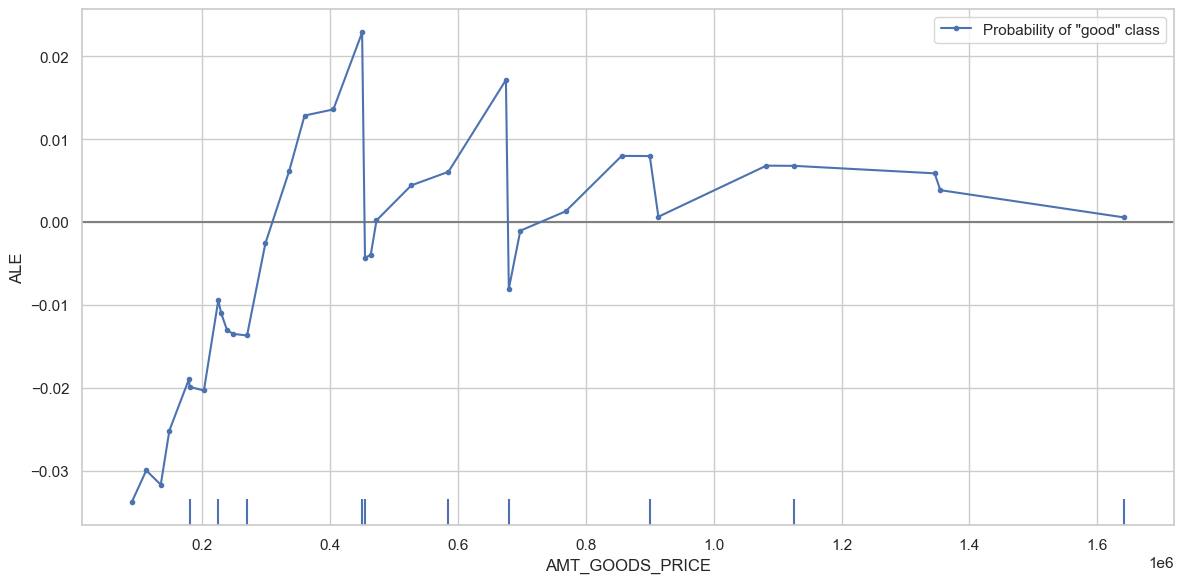

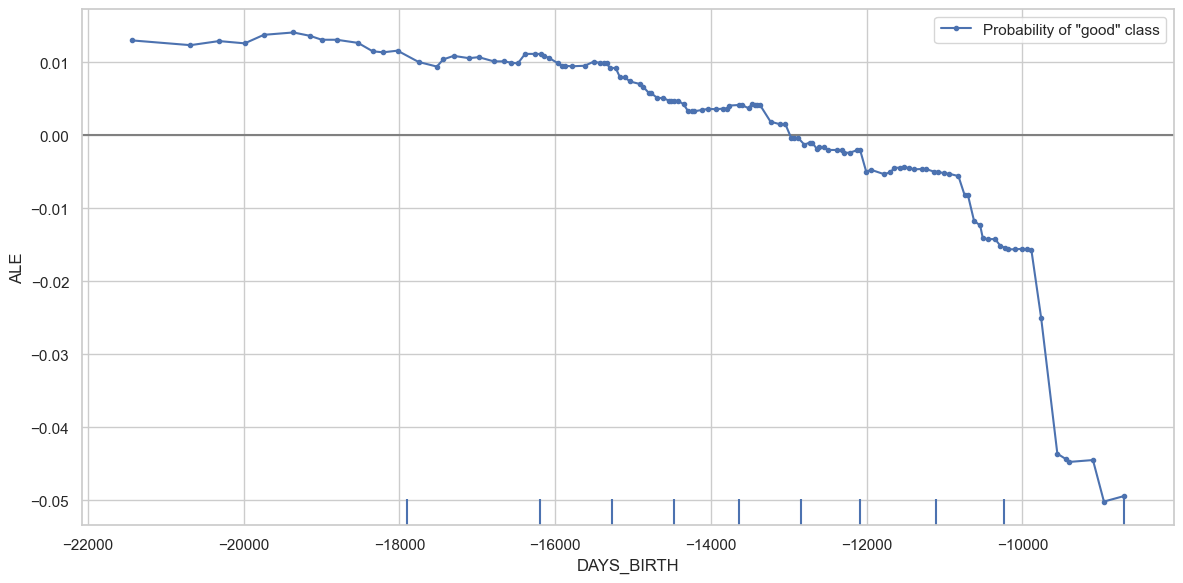

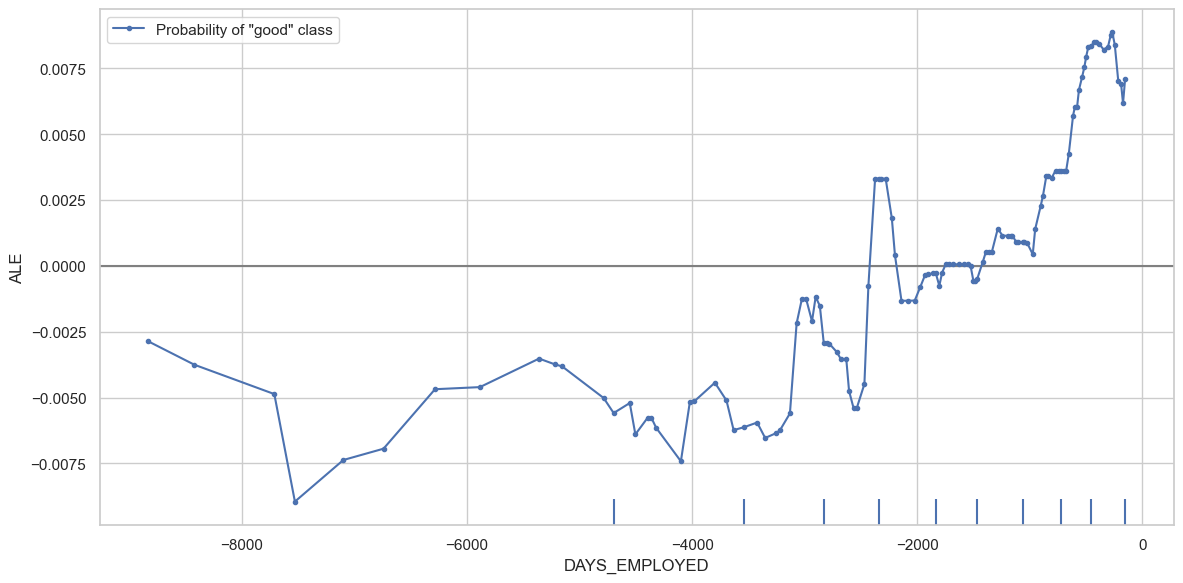

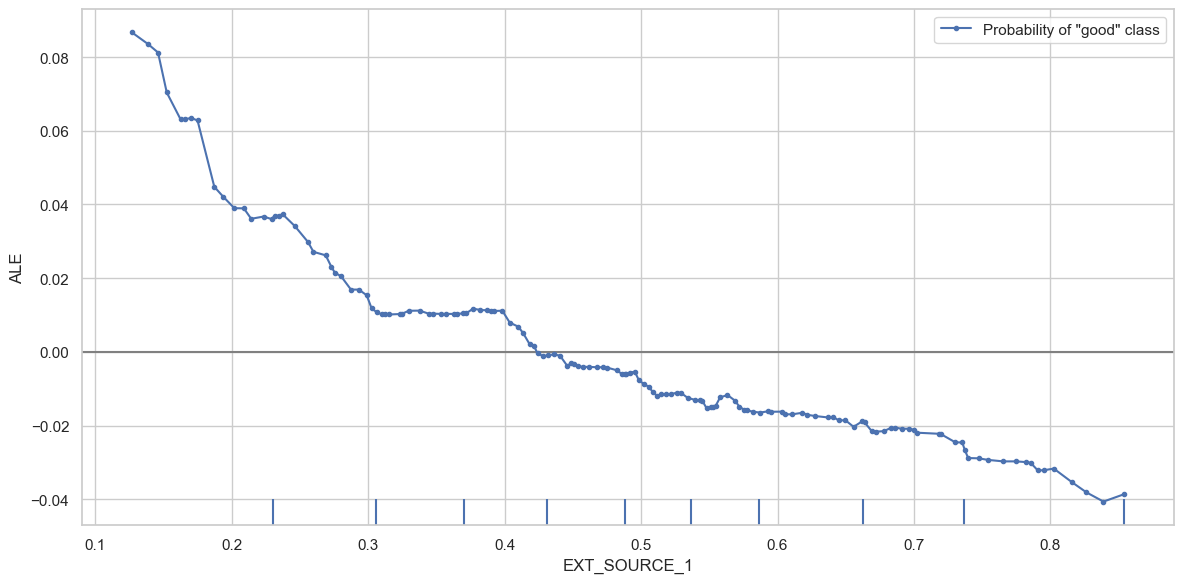

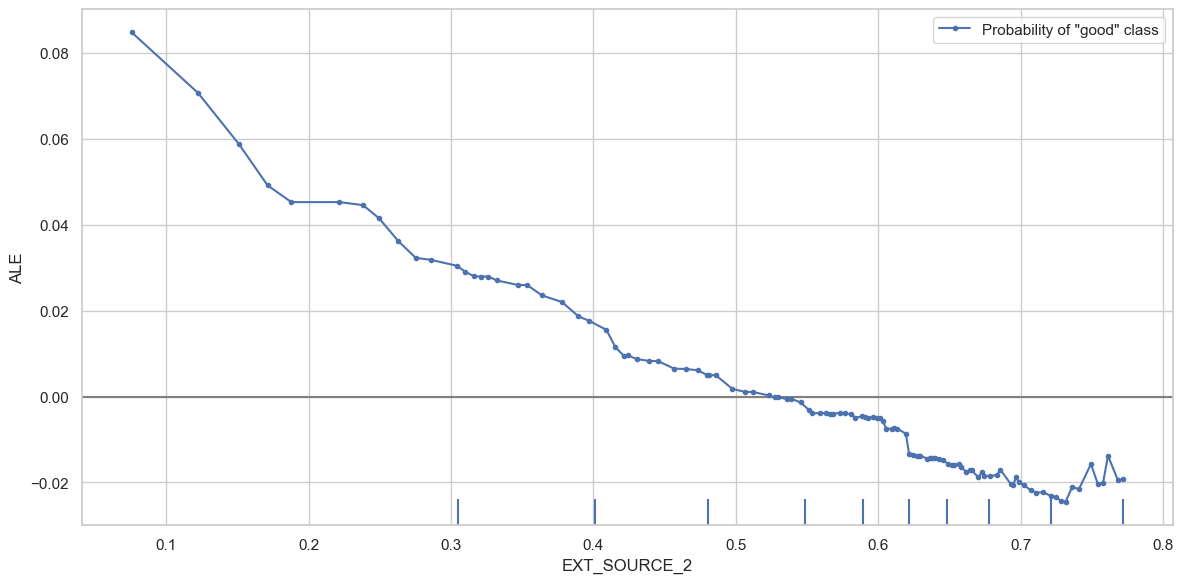

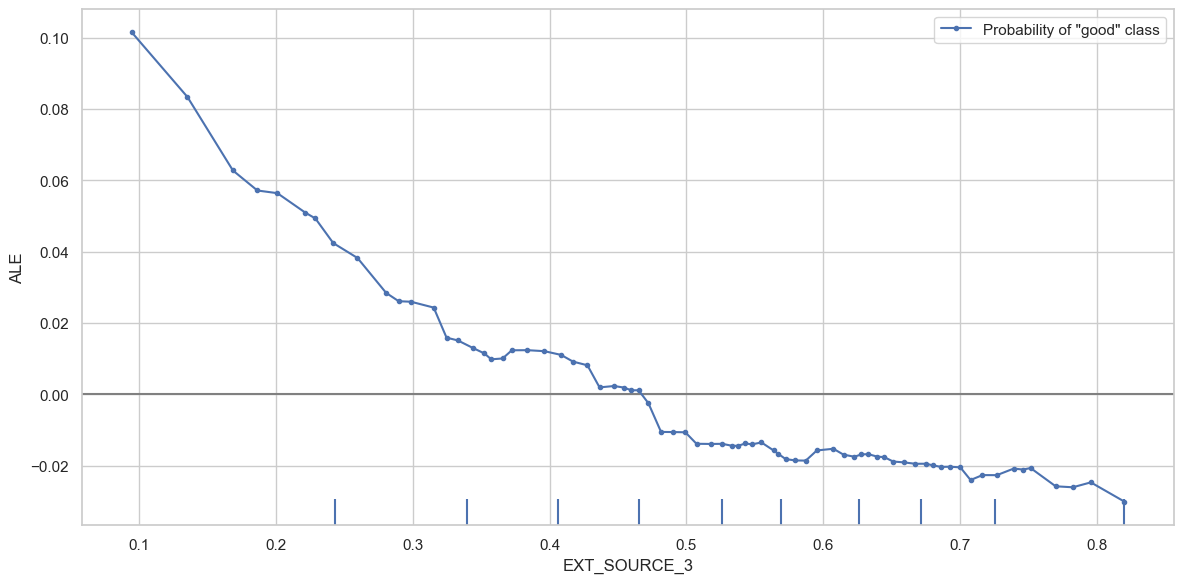

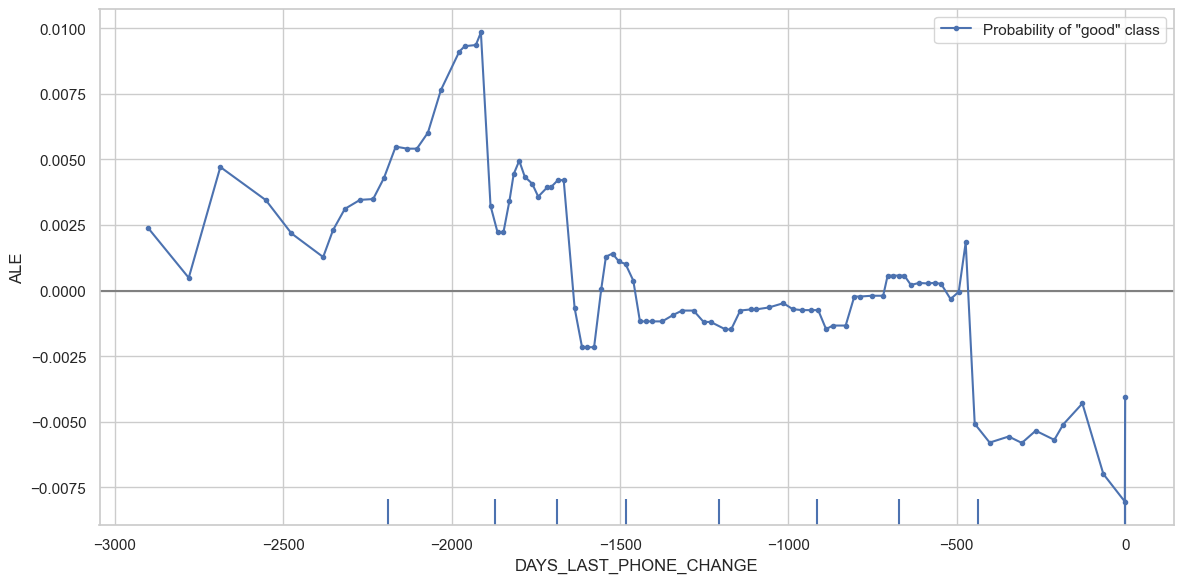

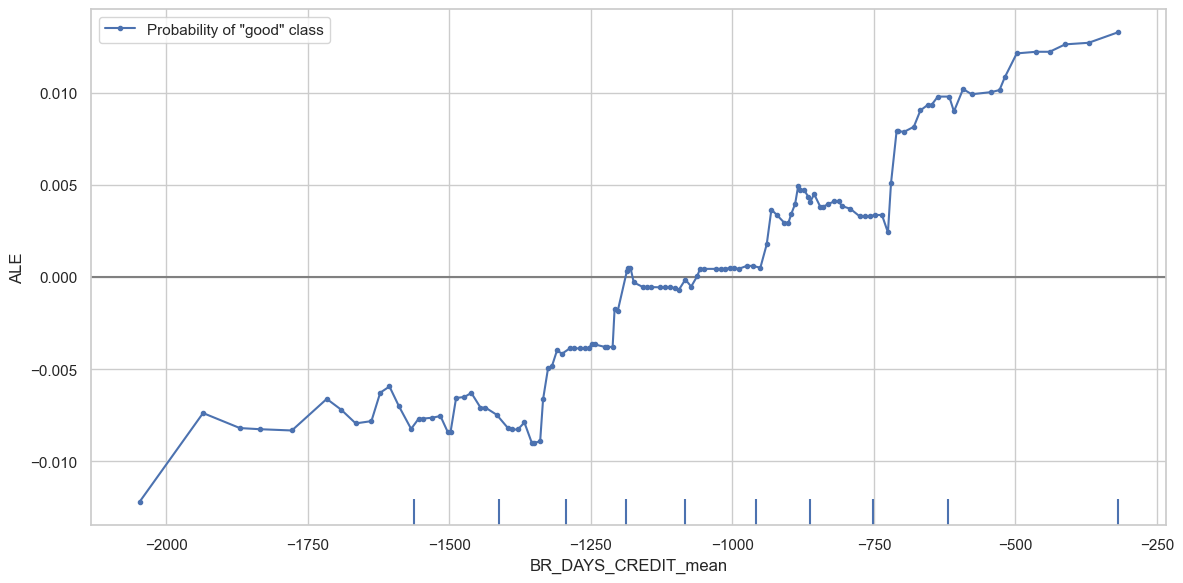

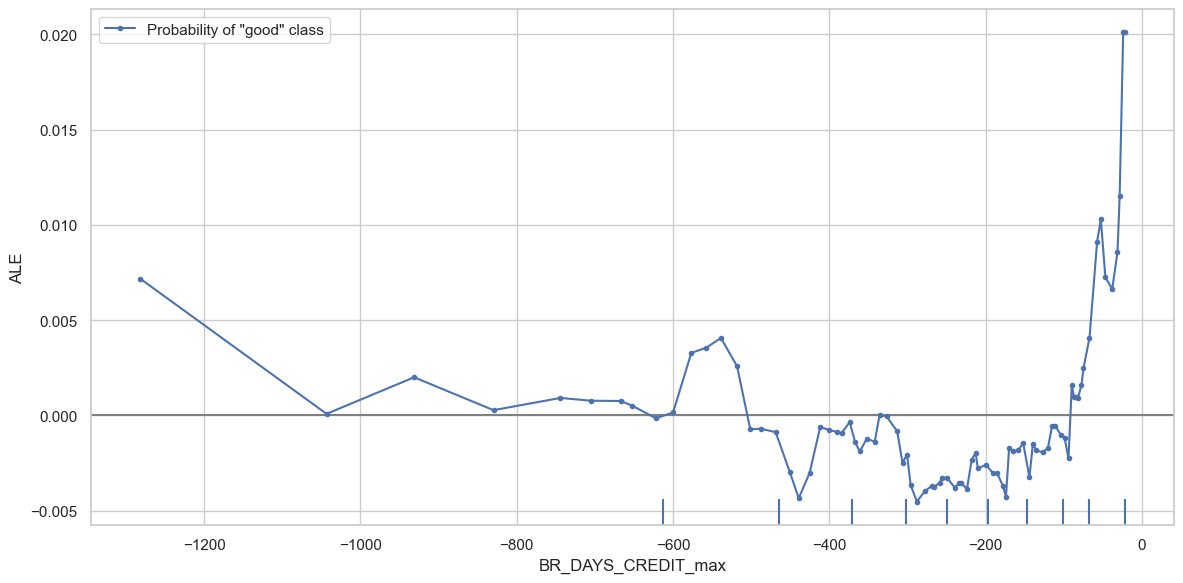

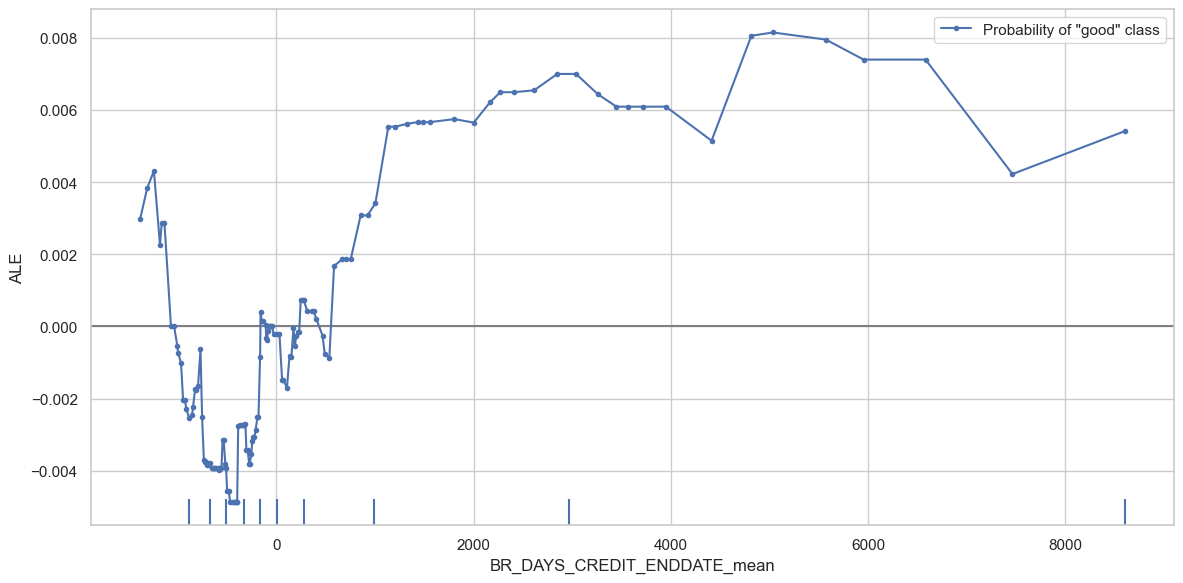

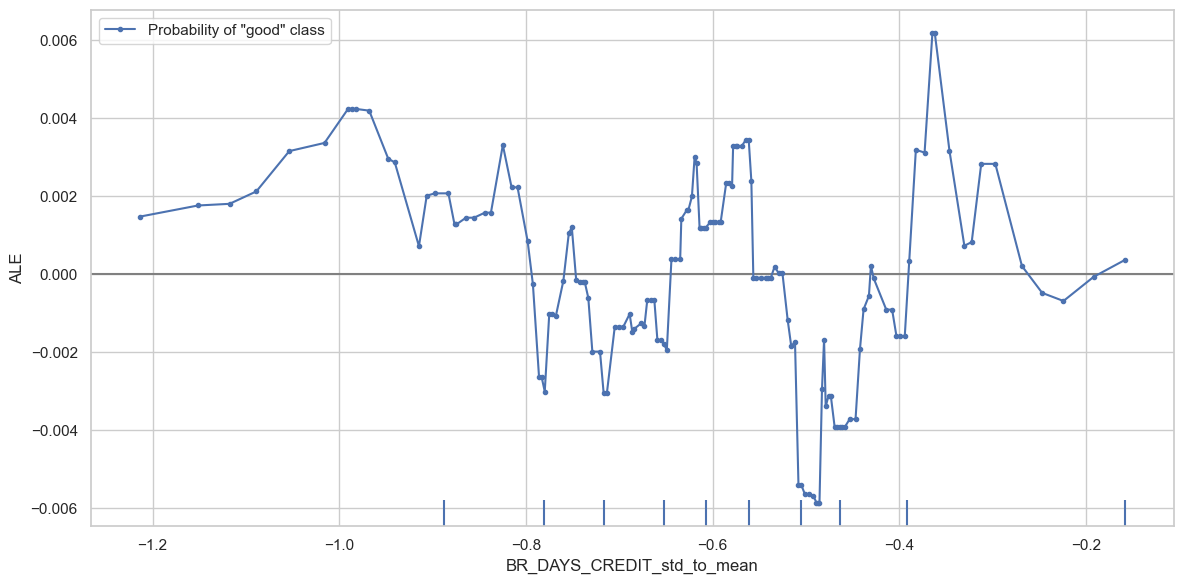

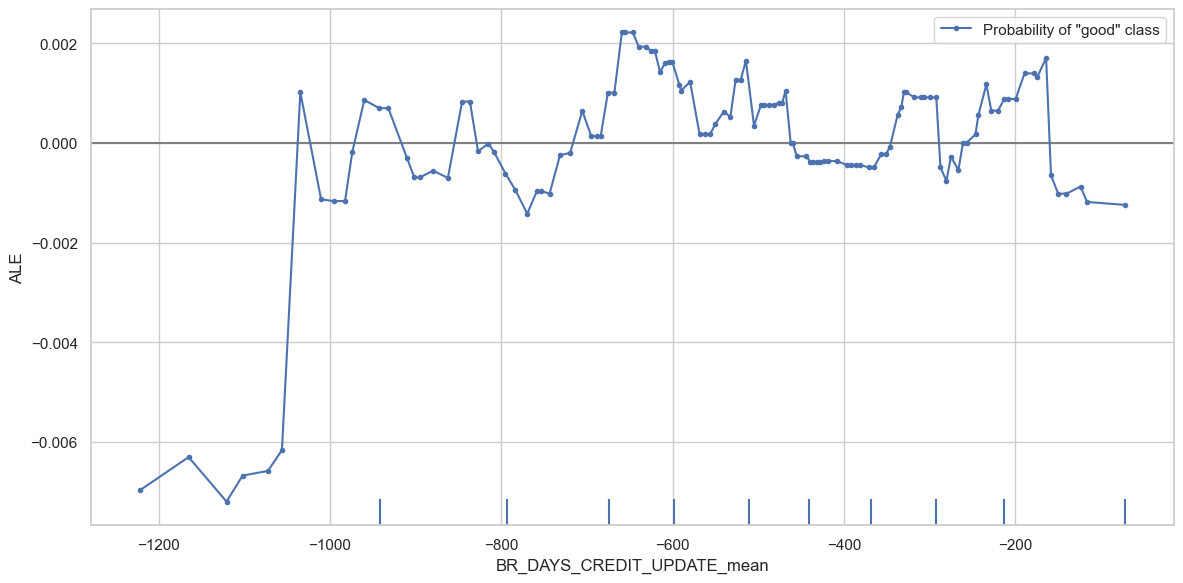

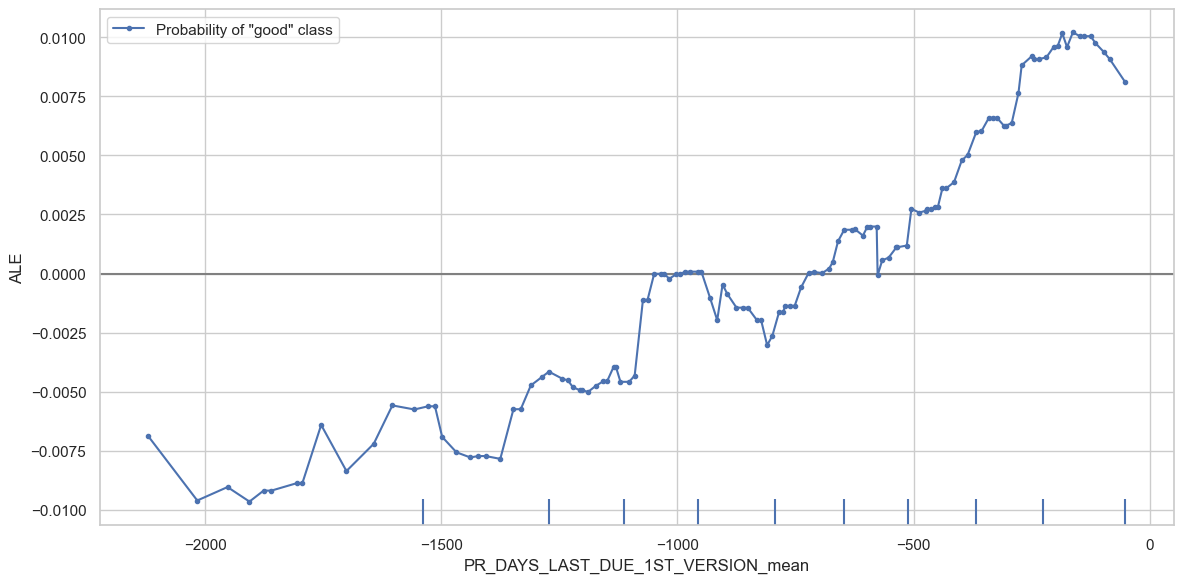

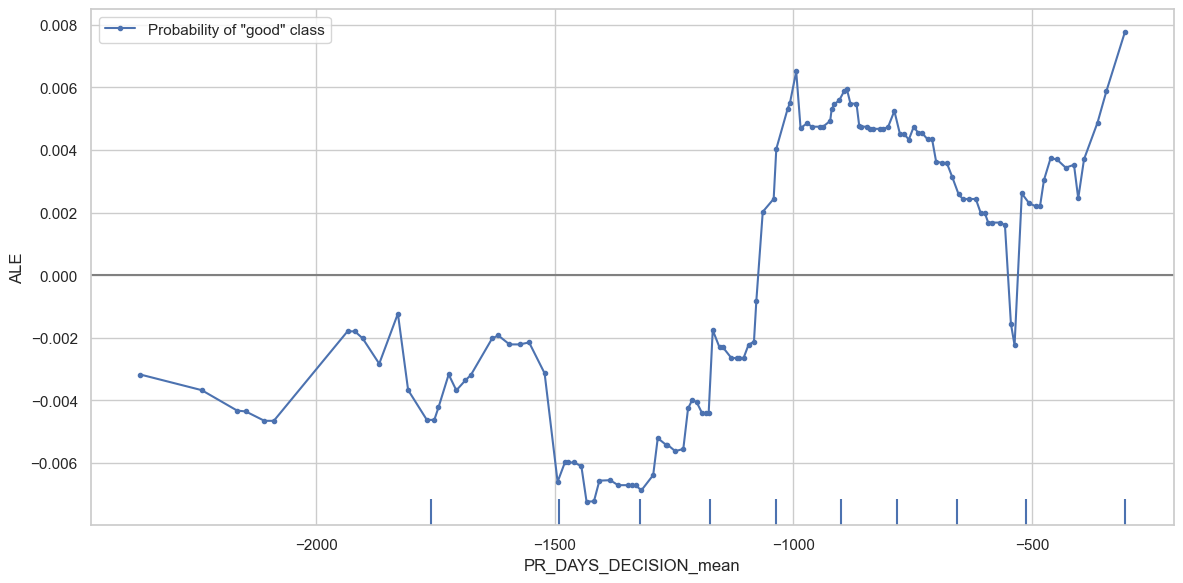

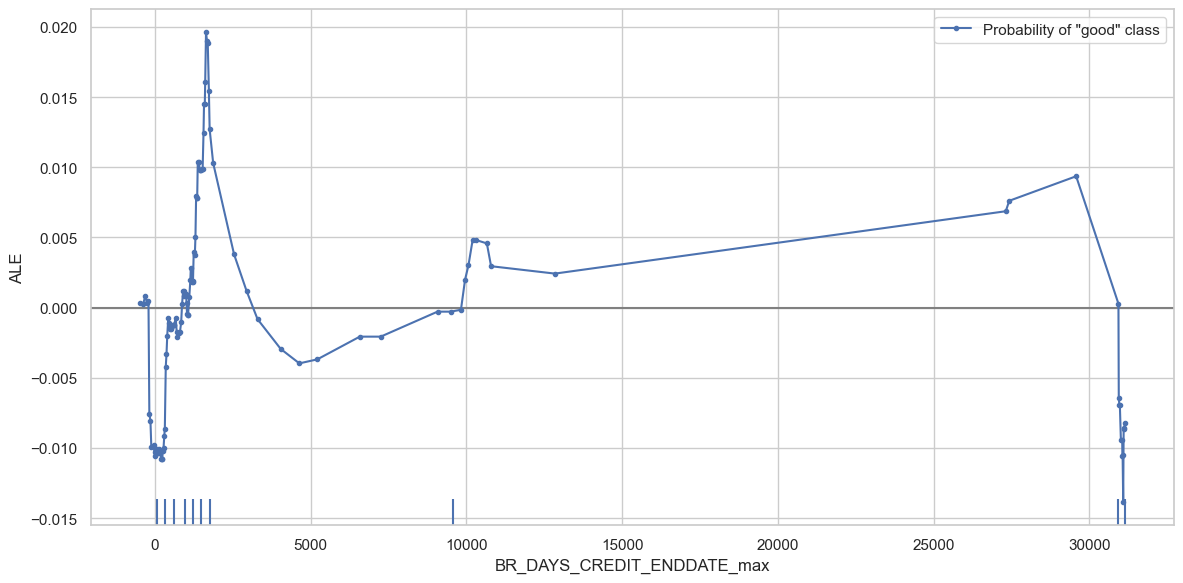

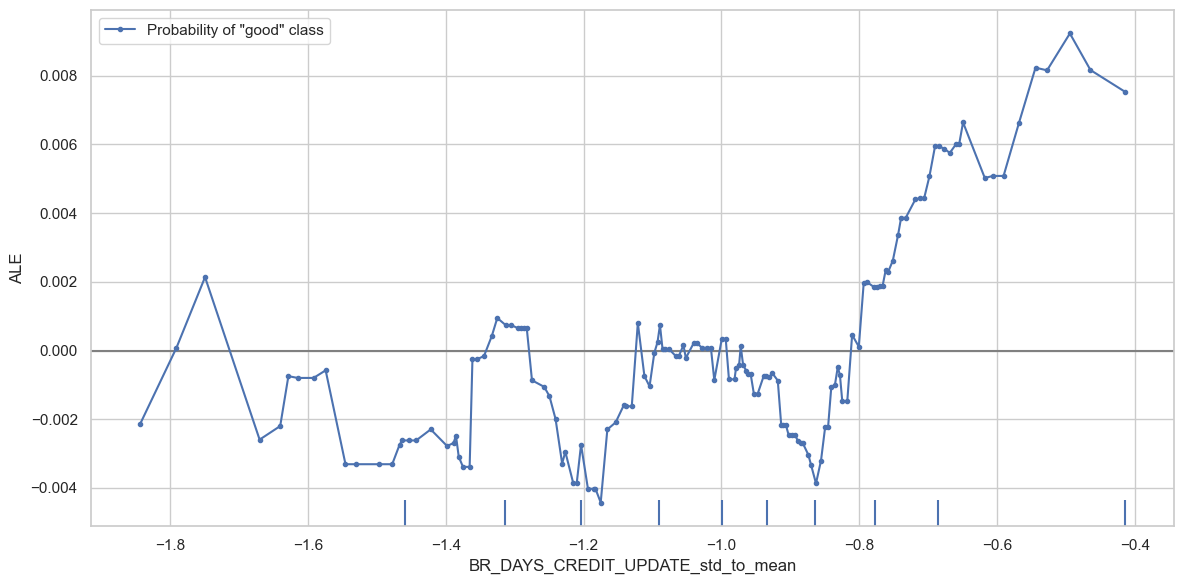

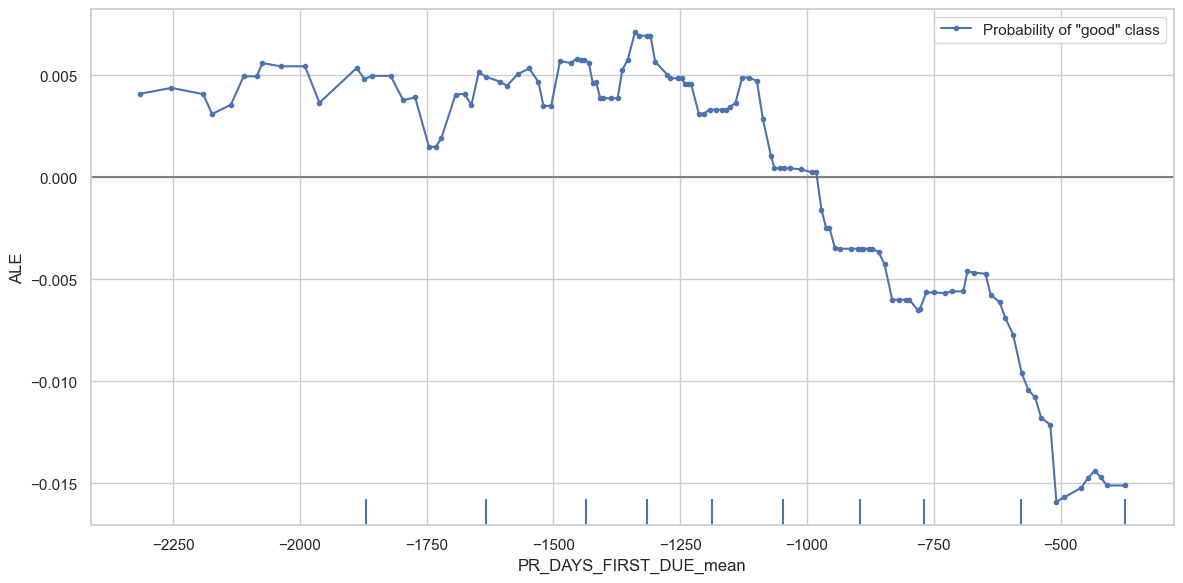

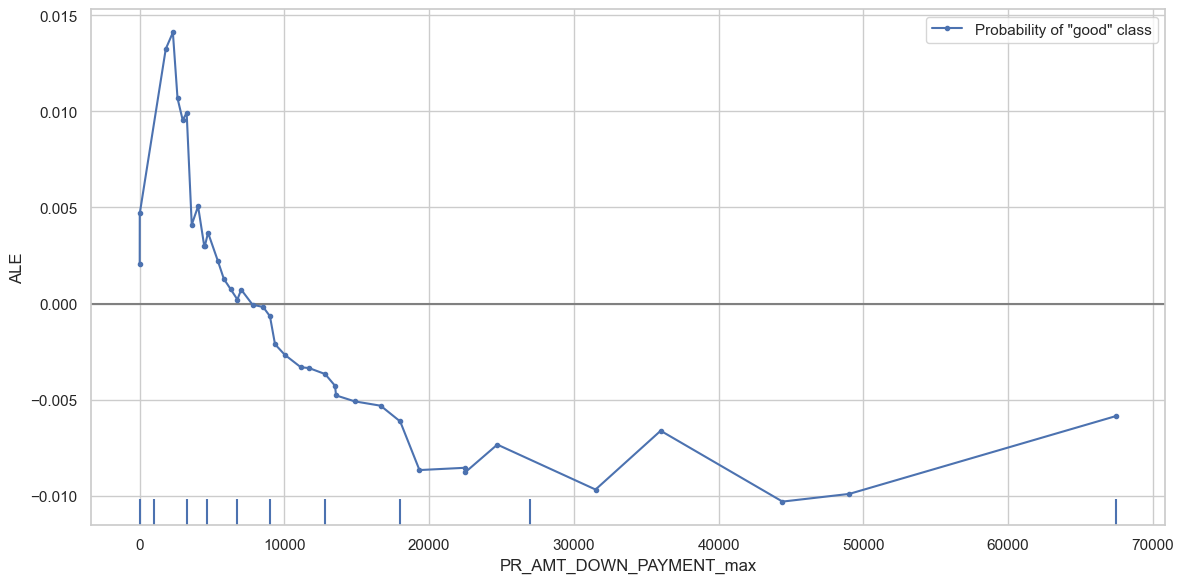

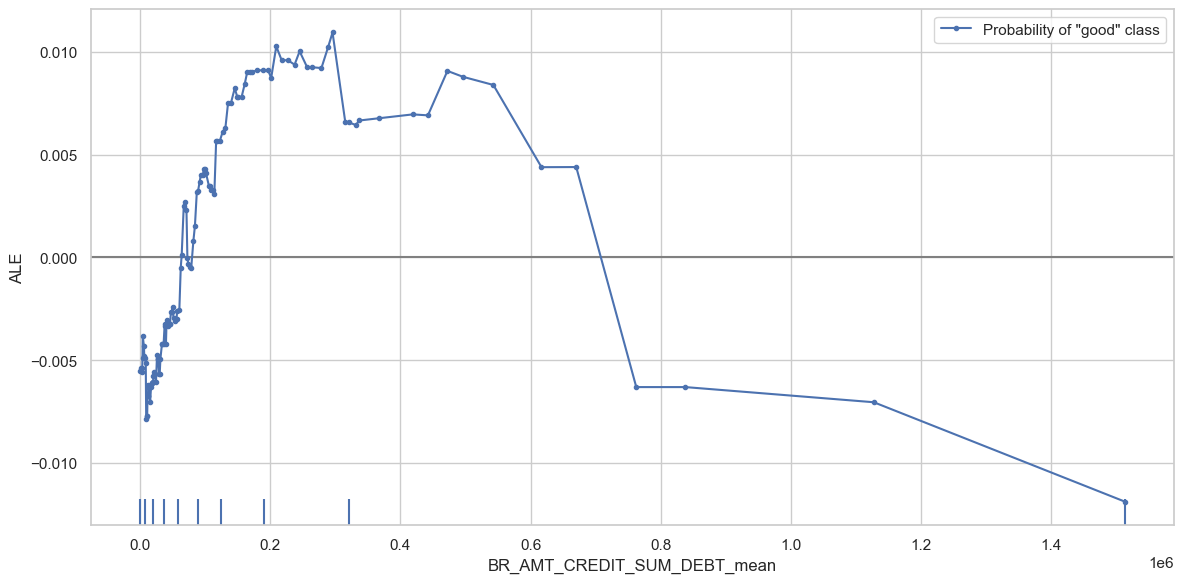

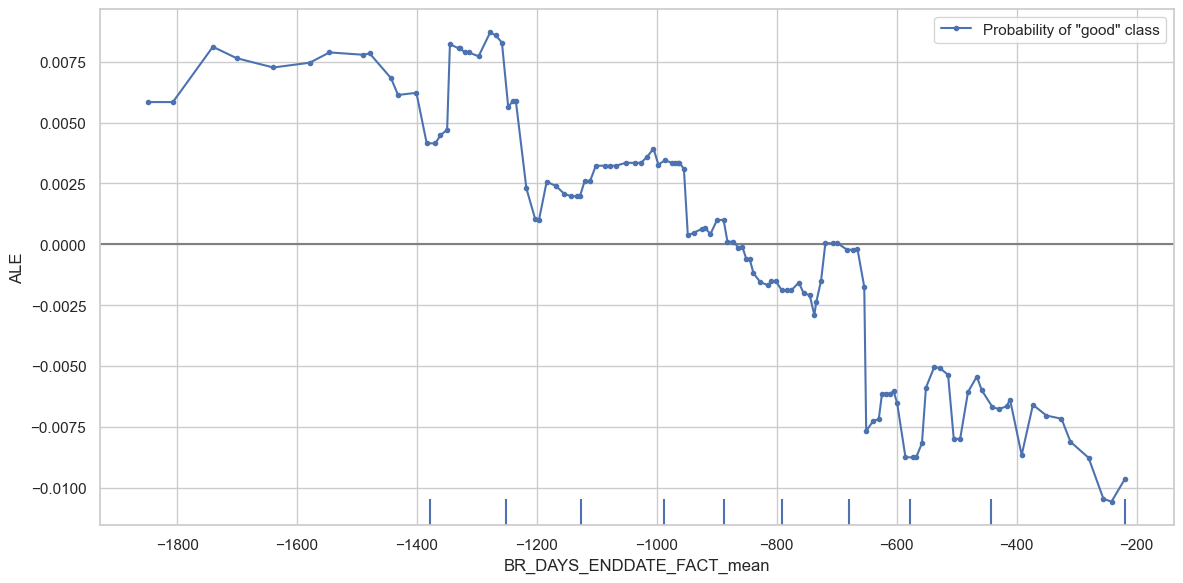

In [80]:
predict_fn = lambda x: calibrated.predict_proba(x)[:, 1]
for feature in features:
    X_sample = X_sample.drop(X_sample[X_sample[feature] > np.quantile(X_sample[feature], 0.98)].index)
    X_sample = X_sample.drop(X_sample[X_sample[feature] < np.quantile(X_sample[feature], 0.02)].index)
for feature in features: 
    ale = ALE(predict_fn, feature_names=features)
    exp = ale.explain(X_sample.to_numpy()) 
    plot_ale(
    exp,
    features=[feature],
    line_kw={'label': 'Probability of "good" class'}
)

In [89]:
X_train_clean = X_train.dropna()
predict_fn = lambda x: model.predict_proba(x)
for id in idx:
    explainer = AnchorTabular(predict_fn, feature_names=features)
    explainer.fit(X_train_clean.values)
    result = explainer.explain(X_train_clean.iloc[id].to_numpy())
    print('Anchor =', result.anchor)
    print('Precision =', result.precision)
    print('Coverage =', result.coverage)

Anchor = ['EXT_SOURCE_1 > 0.52', 'EXT_SOURCE_3 > 0.52']
Precision = 0.9858695652173913
Coverage = 0.2827
Anchor = ['EXT_SOURCE_3 > 0.65', 'EXT_SOURCE_2 > 0.67']
Precision = 0.9770114942528736
Coverage = 0.0707
Anchor = ['EXT_SOURCE_3 <= 0.36', 'EXT_SOURCE_1 <= 0.35', 'EXT_SOURCE_2 <= 0.43', 'BR_DAYS_CREDIT_mean > -776.37']
Precision = 0.9746835443037974
Coverage = 0.0188
Anchor = ['EXT_SOURCE_1 <= 0.35', 'EXT_SOURCE_2 <= 0.43', 'BR_DAYS_CREDIT_mean > -776.37', 'BR_DAYS_CREDIT_max > -130.00', 'EXT_SOURCE_3 <= 0.65', 'DAYS_EMPLOYED > -570.00']
Precision = 0.9568345323741008
Coverage = 0.0048
Anchor = ['EXT_SOURCE_3 > 0.65', 'EXT_SOURCE_1 > 0.35']
Precision = 0.9609120521172638
Coverage = 0.2015
Anchor = ['EXT_SOURCE_3 > 0.65', 'BR_DAYS_CREDIT_ENDDATE_max <= 334.00', 'PR_DAYS_LAST_DUE_1ST_VERSION_mean <= -299.22']
Precision = 0.9726027397260274
Coverage = 0.0561
Anchor = ['EXT_SOURCE_1 > 0.52', 'EXT_SOURCE_3 > 0.36']
Precision = 0.9519306540583137
Coverage = 0.4014
Anchor = ['EXT_SOURCE_1

### 7d. Dalex

In [12]:
explainer = dx.Explainer(
    calibrated,
    X_train,
    y_train,
    label="Credit Model"
)

Preparation of a new explainer is initiated

  -> data              : 246008 rows 20 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 246008 values
  -> model_class       : sklearn.calibration.CalibratedClassifierCV (default)
  -> label             : Credit Model
  -> predict function  : <function yhat_proba_default at 0x0000011ECFAE32E0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.000644, mean = 0.0809, max = 0.944
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.805, mean = -0.000157, max = 0.987
  -> model_info        : package sklearn

A new explainer has been created!


In [20]:
cp = explainer.predict_profile(
    X_test.iloc[[5]],
    variables=features
)

cp.plot()

Calculating ceteris paribus: 100%|██████████| 20/20 [00:00<00:00, 23.51it/s]


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [22]:
import nbformat
print(nbformat.__version__)

ImportError: cannot import name 'encodestring' from 'base64' (c:\Users\stani\miniconda3\envs\explain\lib\base64.py)

In [23]:
python --version

NameError: name 'python' is not defined

## 8. Evaluation & Benchmarking

In [ ]:
# TODO: Implement DiCE counterfactual generation

## 9. Summary & Next Steps

### What you have done:

---

### AI Tools Used

Document any AI tools used during this project:

| Tool | How it was used |
|------|----------------|
| *e.g., ChatGPT* | *e.g., Helped debug LightGBM hyperparameter tuning* |
| | |